# REFMAP laboratory listening test 1 analysis: Rough confirmatory data analysis

## Setup

In [1]:
# import packages
import sys
import os
import numpy as np
import pandas as pd
from PyQt5.QtWidgets import QFileDialog, QApplication
from scipy import stats
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.collections import PathCollection
from matplotlib.legend_handler import HandlerPathCollection, HandlerLine2D
import seaborn as sns
import dabest
import warnings

# Suppress FutureWarning messages to quiet pandas
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 18.01it/s]

Numba compilation complete!


In [2]:
# set plot parameters
sns.set_style('white')
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams.update({'font.size': 16})
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['mathtext.fontset'] = 'stix'

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE,
       labelsize=MEDIUM_SIZE)    # fontsize of the axes title and x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

mycolours = [(0, 102, 255), (0, 204, 153), (255, 0, 102), (74, 111, 152),
             (251, 164, 49), (204, 153, 255), (90, 192, 255), (80, 245, 233),
             (255, 90, 192), (164, 201, 242), (255, 254, 139), (255, 243, 255)]
mycolours = [tuple(shade/255 for shade in colour) for colour in mycolours]

np.random.seed(303)

# enable copy-on-write mode for Pandas (will be default from Pandas 3.0)
pd.options.mode.copy_on_write = True

# check/open QApplication instance
if not QApplication.instance():
    app = QApplication(sys.argv)
else:
    app = QApplication.instance() 


Set the saveplots toggle to True if plot saving is desired:

In [ ]:
saveplots = False

if saveplots:
    # select figure output save path
    outFigPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save plots in: 03 Experiment\Experiment 1\Analysis\Plots")

    # create subfolders if not already existing
    try:
        os.mkdir(os.path.join(outFigPath, "svg"))
    except FileExistsError:
        pass

    try:
        os.mkdir(os.path.join(outFigPath, "pdf"))
    except FileExistsError:
        pass


## Import data and organise

In [4]:
# import test data
fileExts = "*.csv"

# Part A
dataBySubjAFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest1_testdataA_BySubj.csv",
                                                       caption=r"Open refmap_listest1_testdataA_BySubj.csv in: \03 Experiment\Experiment 1\Analysis\PostProcess"))[0]
dataBySubjTestA = pd.read_csv(dataBySubjAFilePath)

# Part B
dataBySubjBFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest1_testdataB_BySubj.csv",
                                                       caption=r"Open refmap_listest1_testdataB_BySubj.csv in: \03 Experiment\Experiment 1\Analysis\PostProcess"))[0]
dataBySubjTestB = pd.read_csv(dataBySubjBFilePath)

# Both parts
dataBySubjFilePath = list(QFileDialog.getOpenFileName(filter="refmap_listest1_testdata_BySubj.csv",
                                                       caption=r"Open refmap_listest1_testdata_BySubj.csv in: \03 Experiment\Experiment 1\Analysis\PostProcess"))[0]
dataBySubjTest = pd.read_csv(dataBySubjFilePath)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_1140\531397316.py:7: DtypeWarning: Columns (395) have mixed types. Specify dtype option on import or set low_memory=False.
  dataBySubjTestA = pd.read_csv(dataBySubjAFilePath)


In [5]:
# categorise columns

for dataset in [dataBySubjTestA, dataBySubjTest]:
    dataset['AmbientEnv'] = pd.Categorical(dataset['AmbientEnv'], ["Park", "Street"])
    dataset['SNRlevel'] = pd.Categorical(dataset['SNRlevel'], ["Baseline", "-16", "-10", "-4", "2", "8"], ordered=True)
    dataset['UASLAeq'] = pd.Categorical(dataset['UASLAeq'], ["Baseline", "42", "48", "54", "60"], ordered=True)
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Baseline", "Overflight", "Landing", "Takeoff"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["Baseline", "H520", "M300", "T150"])

for dataset in [dataBySubjTestB]:
    dataset['AmbientEnv'] = pd.Categorical(dataset['AmbientEnv'], ["Park", "Street"])
    dataset['SNRlevel'] = pd.Categorical(dataset['SNRlevel'], ["Baseline", "2", "8"], ordered=True)
    dataset['UASLAeq'] = pd.Categorical(dataset['UASLAeq'], ["Baseline", "54", "60"], ordered=True)
    dataset['UASOperation'] = pd.Categorical(dataset['UASOperation'], ["Baseline", "Overflight"])
    dataset['UASType'] = pd.Categorical(dataset['UASType'], ["Baseline", "H520", "T150"])


## Setup output dataframes

In [6]:
out = pd.DataFrame()
outd = pd.DataFrame()

savedata = False

if savedata:
    # select data output save path
    outDataPath = QFileDialog.getExistingDirectory(caption=r"Select output folder to save output data in: \03 Experiment\Experiment 1\Analysis\Python")


## Part A

### Scaled vs modelled UAS LAeq level 2 

In [7]:
# select subset of data for analysis and sort
data = dataBySubjTestA[dataBySubjTestA['StimFile'].str.contains("_F_2")]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'Annoyance']]
data.sort_values(by=['ID', 'StimFile'], inplace=True)

# add column to indicate modelled or scaled, and create a dummy pairing ID
data['LvlType'] = "Modelled"
data.loc[data['StimFile'].str.contains("PwrScale"), 'LvlType'] = "Scaled"
data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['LvlType'].unique()) + 1, dtype=int), len(data['LvlType'].unique()), axis=0)



In [9]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=("Modelled", "Scaled"), x='LvlType', y='Annoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=303)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Modelled,Scaled,246,246,mean difference,baseline,0.056911,95,-0.195122,0.317073,0.647471,0.69952,7362.0,0.662346,-0.437207


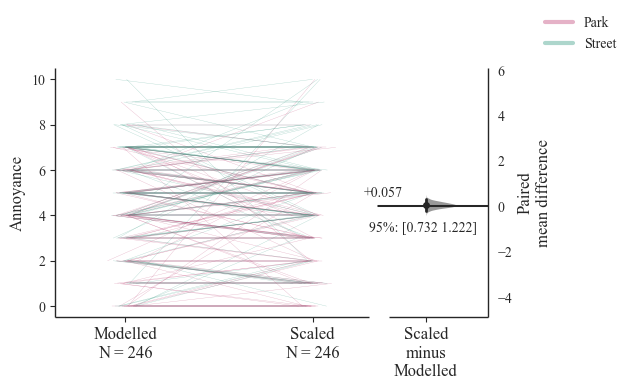

In [ ]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 4))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='AmbientEnv',
                                   contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.4},
                                   slopegraph_xjitter=0.03, slopegraph_yjitter=0.0, jitter_seed=303,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette=mycolours[1:3], es_marker_size=4, contrast_ylim=(-5.5, 4.5),
                                   legend_kwargs={'loc': 'lower center'}, ax=ax)

diffs = dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values

axs = dataMD.axes

annotation = axs[0].findobj(mpl.text.Annotation)
annotation[0].set_y(5.5)

# label results
ax.text(x=1.3, y=3.25, s="95%: " + str(diffs[1:]), fontsize=10)

lgd = axs[0].get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(1)
    lh.set_linewidth(3)

if saveplots:
    
    filename = "PtALvlScaleDabest"
    
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [34]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Modelled,Scaled,246,246,Cohen's d,baseline,0.0239,95,-0.079853,0.134437,0.647471,0.69952,7362.0,0.662346,-0.437207


### UAS LAeq segregated by ambient environment

In [8]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['ID', 'AmbientEnv', 'UASOperation', 'UASType', 'UASLAeq'], inplace=True)

dataPk = data.loc[data['AmbientEnv'] == "Park", :]
dataSt = data.loc[data['AmbientEnv'] == "Street", :]

# create a dummy pairing ID
dataPk['dummyID'] = np.repeat(np.arange(1, len(dataPk['ID'])//len(dataPk['UASLAeq'].unique()) + 1, dtype=int), len(dataPk['UASLAeq'].unique()), axis=0)
dataSt['dummyID'] = np.repeat(np.arange(1, len(dataSt['ID'])//len(dataSt['UASLAeq'].unique()) + 1, dtype=int), len(dataSt['UASLAeq'].unique()), axis=0)


In [131]:
# assign data for processing
dataPkloadSQ = dabest.load(data=dataPk, idx=("42", "48", "54", "60"), x='UASLAeq', y='Annoyance', paired='sequential',
                           id_col='dummyID', resamples=5000, random_seed=303)
dataStloadSQ = dabest.load(data=dataSt, idx=("42", "48", "54", "60"), x='UASLAeq', y='Annoyance', paired='sequential',
                           id_col='dummyID', resamples=5000, random_seed=808)

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\497257804.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\497257804.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\497257804.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,mean difference,sequential,0.951220,95,0.728997,1.176152,0.0002,1.012021e-15,8576.0,2.420381e-15,-8.273149
1,48,54,369,369,mean difference,sequential,0.861789,95,0.620596,1.089431,0.0002,2.516079e-13,10578.5,5.236929e-12,-7.133314
2,54,60,369,369,mean difference,sequential,0.978320,95,0.731707,1.222222,0.0002,1.623886e-12,10817.5,1.563889e-13,-7.669002


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


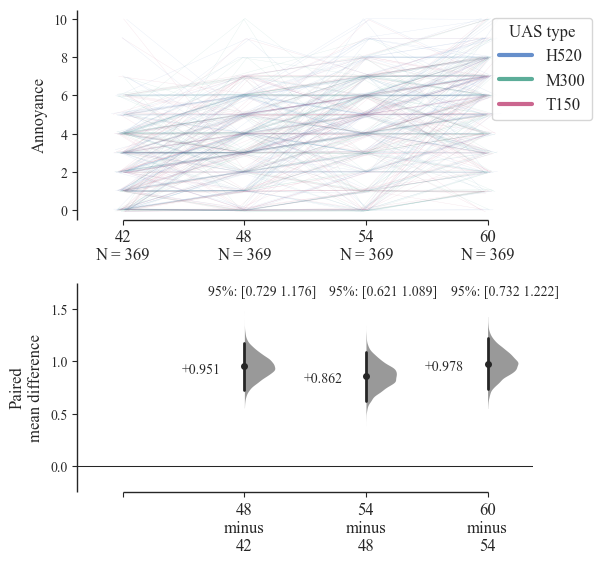

In [41]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataPkMD = dataPkloadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASType',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.15},
                                       slopegraph_xjitter=0.03, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours, es_marker_size=4, contrast_ylim=(-0.25, 1.75), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS type", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataPkloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    filename = "PtALAeqParkDabest"
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadSQ.mean_diff.statistical_tests


In [25]:
out = pd.concat([out, dataPkloadSQ.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadSQ.cohens_d.statistical_tests])
dataPkloadSQ.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,Cohen's d,sequential,0.455334,95,0.344373,0.568954,0.0002,1.012021e-15,8576.0,2.420381e-15,-8.273149
1,48,54,369,369,Cohen's d,sequential,0.375490,95,0.267149,0.482397,0.0002,2.516079e-13,10578.5,5.236929e-12,-7.133314
2,54,60,369,369,Cohen's d,sequential,0.401178,95,0.301119,0.502650,0.0002,1.623886e-12,10817.5,1.563889e-13,-7.669002


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\801205713.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\801205713.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\801205713.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,mean difference,sequential,0.371274,95,0.159892,0.577236,0.0004,6.386729e-04,12043.5,6.801265e-04,-3.426642
1,48,54,369,369,mean difference,sequential,0.384824,95,0.162602,0.607046,0.0008,1.502871e-04,13070.0,6.531619e-04,-3.437966
2,54,60,369,369,mean difference,sequential,0.959350,95,0.734417,1.197832,0.0002,6.468262e-16,9045.5,4.711984e-15,-8.178623


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


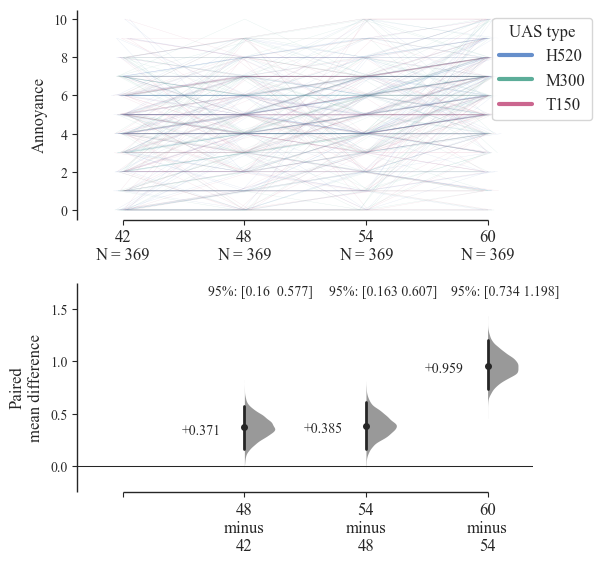

In [132]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataStMD = dataStloadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASType',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.15},
                                       slopegraph_xjitter=0.03, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours, es_marker_size=4, contrast_ylim=(-0.25, 1.75), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS type", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataStloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    filename = "PtALAeqStreetDabest"
    plt.savefig(os.path.join(outFigPath, "svg", filename + ".svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", filename + ".pdf"),
                format='pdf', bbox_inches='tight')

dataStMD;
dataStloadSQ.mean_diff.statistical_tests


In [27]:
out = pd.concat([out, dataStloadSQ.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadSQ.cohens_d.statistical_tests])
dataStloadSQ.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,42,48,369,369,Cohen's d,sequential,0.155188,95,0.066208,0.243645,0.0004,6.386729e-04,12043.5,6.801265e-04,-3.426642
1,48,54,369,369,Cohen's d,sequential,0.162379,95,0.068055,0.256107,0.0008,1.502871e-04,13070.0,6.531619e-04,-3.437966
2,54,60,369,369,Cohen's d,sequential,0.403855,95,0.306873,0.512212,0.0002,6.468262e-16,9045.5,4.711984e-15,-8.178623


### UAS types and operations segregated by ambient environment

#### UAS type

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASType'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['ID', 'UASLAeq', 'UASOperation', 'UASType', 'AmbientEnv'], inplace=True)

dataPk = data.loc[data['AmbientEnv'] == "Park", :]
dataSt = data.loc[data['AmbientEnv'] == "Street", :]

# create a dummy pairing ID
dataPk['dummyID'] = np.repeat(np.arange(1, len(dataPk['ID'])//len(dataPk['UASType'].unique()) + 1, dtype=int), len(dataPk['UASType'].unique()), axis=0)
dataSt['dummyID'] = np.repeat(np.arange(1, len(dataSt['ID'])//len(dataSt['UASType'].unique()) + 1, dtype=int), len(dataSt['UASType'].unique()), axis=0)


In [188]:
# assign data for processing
dataPkloadBL = dabest.load(data=dataPk, idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                           id_col='dummyID', resamples=5000, random_seed=808)
dataStloadBL = dabest.load(data=dataSt, idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                           id_col='dummyID', resamples=5000, random_seed=808)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3941078211.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtATypeParkDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3941078211.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeParkDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3941078211.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeParkDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,mean difference,baseline,-0.357724,95,-0.567073,-0.152439,0.0006,0.001376,23542.0,0.000754,3.390566
1,H520,T150,492,492,mean difference,baseline,-0.449187,95,-0.658537,-0.241870,0.0010,0.000021,27984.5,0.000028,4.231828


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


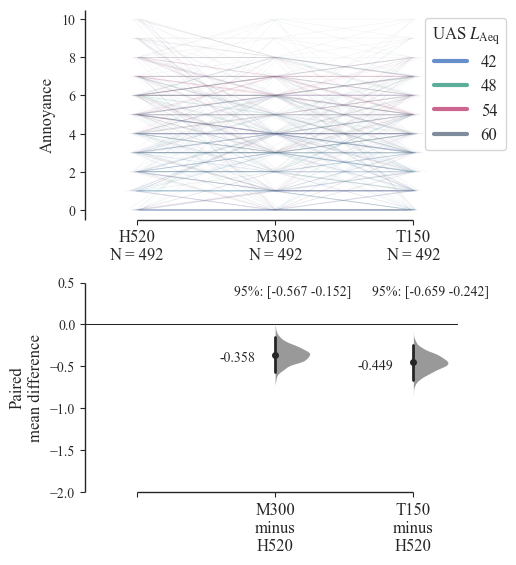

In [138]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataPkMD = dataPkloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                       slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours, es_marker_size=4, contrast_ylim=(-2, 0.5), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = dataPkloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values
# label results
for ii, diffrow in enumerate(np.round(diffs, 3)):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtATypeParkDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeParkDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadBL.mean_diff.statistical_tests


In [31]:
out = pd.concat([out, dataPkloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadBL.cohens_d.statistical_tests])
dataPkloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,Cohen's d,baseline,-0.143211,95,-0.224773,-0.060372,0.0006,0.001376,23542.0,0.000754,3.390566
1,H520,T150,492,492,Cohen's d,baseline,-0.177829,95,-0.261016,-0.094142,0.0010,0.000021,27984.5,0.000028,4.231828


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\558804196.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtATypeStreetDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\558804196.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeStreetDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\558804196.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeStreetDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,mean difference,baseline,-0.085366,95,-0.268293,0.097561,0.350530,0.205018,27046.0,0.374111,0.889610
1,H520,T150,492,492,mean difference,baseline,-0.197154,95,-0.376016,-0.022358,0.030194,0.006711,23282.5,0.031394,2.158231


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


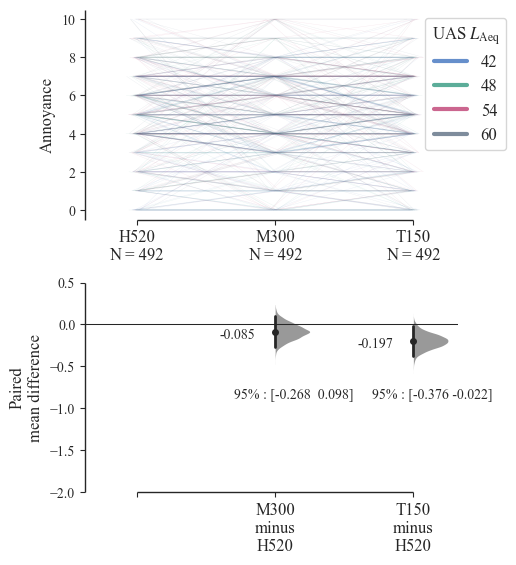

In [139]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataStMD = dataStloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                       slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=54554,
                                       custom_palette=mycolours, es_marker_size=4, contrast_ylim=(-2, 0.5), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataStloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-9.2, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-9.9, s="95% : " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtATypeStreetDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeStreetDabest.pdf"),
                format='pdf', bbox_inches='tight')


dataStMD;
dataStloadBL.mean_diff.statistical_tests


In [33]:
out = pd.concat([out, dataStloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadBL.cohens_d.statistical_tests])
dataStloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,492,492,Cohen's d,baseline,-0.034743,95,-0.108488,0.041185,0.350530,0.205018,27046.0,0.374111,0.889610
1,H520,T150,492,492,Cohen's d,baseline,-0.079948,95,-0.151371,-0.008359,0.030194,0.006711,23282.5,0.031394,2.158231


In [140]:
# assign data for processing
dataPkHiloadBL = dabest.load(data=dataPk.loc[dataPk['UASLAeq'] == '60'], idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                             id_col='dummyID', resamples=5000, random_seed=12345)
dataStHiloadBL = dabest.load(data=dataSt.loc[dataSt['UASLAeq'] == '60'], idx=("H520", "M300", "T150"), x='UASType', y='Annoyance', paired='baseline',
                             id_col='dummyID', resamples=5000, random_seed=999)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2964975378.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtATypeParkHiDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2964975378.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeParkHiDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2964975378.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeParkHiDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,mean difference,baseline,-0.943089,95,-1.382114,-0.504065,0.0004,0.000034,1083.5,0.000043,4.245150
1,H520,T150,123,123,mean difference,baseline,-0.747967,95,-1.219512,-0.325203,0.0024,0.001863,1938.0,0.001167,3.325376


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


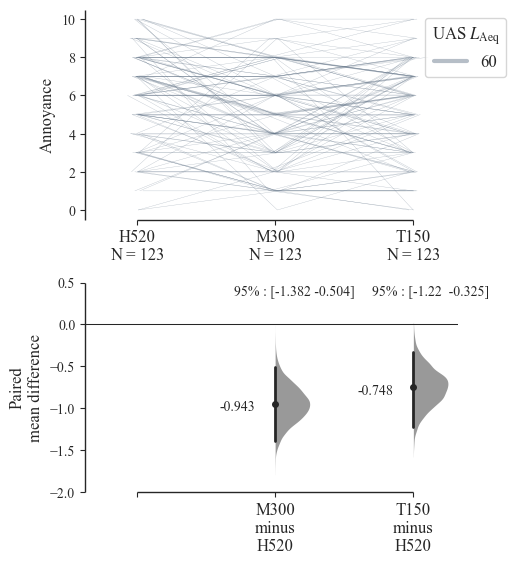

In [189]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataPkHiMD = dataPkHiloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                           contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45},
                                           slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                           custom_palette=mycolours[3:], es_marker_size=4, contrast_ylim=(-2, 0.5), float_contrast=True,
                                           contrast_show_es=True, es_sf=3,                                           
                                           legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                          'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataPkHiloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95% : " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtATypeParkHiDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeParkHiDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataPkHiMD;
dataPkHiloadBL.mean_diff.statistical_tests


In [36]:
out = pd.concat([out, dataPkHiloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkHiloadBL.cohens_d.statistical_tests])
dataPkHiloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,Cohen's d,baseline,-0.385177,95,-0.569867,-0.198468,0.0004,0.000034,1083.5,0.000043,4.245150
1,H520,T150,123,123,Cohen's d,baseline,-0.306181,95,-0.497649,-0.124149,0.0024,0.001863,1938.0,0.001167,3.325376


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3705821754.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtATypeStreetHiDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3705821754.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeStreetHiDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3705821754.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeStreetHiDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,mean difference,baseline,-0.219512,95,-0.650407,0.170732,0.315337,0.263260,1773.5,0.297701,1.045843
1,H520,T150,123,123,mean difference,baseline,-0.341463,95,-0.666667,-0.040650,0.039192,0.026306,1334.0,0.032420,2.163910


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


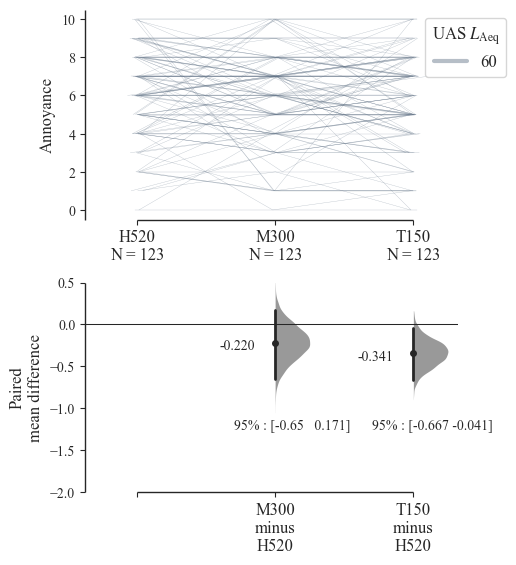

In [190]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataStHiMD = dataStHiloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                           contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45},
                                           slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                           custom_palette=mycolours[3:], es_marker_size=4, contrast_ylim=(-2, 0.5), float_contrast=True,
                                           contrast_show_es=True, es_sf=3,
                                           legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                          'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataStHiloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.2, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-11.5, s="95% : " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtATypeStreetHiDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeStreetHiDabest.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataStHiloadBL.mean_diff.statistical_tests])

dataStHiMD;
dataStHiloadBL.mean_diff.statistical_tests


In [38]:
out = pd.concat([out, dataStHiloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStHiloadBL.cohens_d.statistical_tests])
dataStHiloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,H520,M300,123,123,Cohen's d,baseline,-0.092979,95,-0.275418,0.075336,0.315337,0.263260,1773.5,0.297701,1.045843
1,H520,T150,123,123,Cohen's d,baseline,-0.142476,95,-0.281317,-0.015878,0.039192,0.026306,1334.0,0.032420,2.163910


#### Flight operation

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASType'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['ID', 'UASLAeq', 'UASType', 'AmbientEnv', 'UASOperation'], inplace=True)

dataPk = data.loc[data['AmbientEnv'] == "Park", :]
dataSt = data.loc[data['AmbientEnv'] == "Street", :]

# create a dummy pairing ID
data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['UASOperation'].unique()) + 1, dtype=int), len(data['UASOperation'].unique()), axis=0)
dataPk['dummyID'] = np.repeat(np.arange(1, len(dataPk['ID'])//len(dataPk['UASOperation'].unique()) + 1, dtype=int), len(dataPk['UASOperation'].unique()), axis=0)
dataSt['dummyID'] = np.repeat(np.arange(1, len(dataSt['ID'])//len(dataSt['UASOperation'].unique()) + 1, dtype=int), len(dataSt['UASOperation'].unique()), axis=0)


In [ ]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=("Overflight", "Landing", "Takeoff"), x='UASOperation', y='Annoyance',
                         paired='baseline', id_col='dummyID', resamples=5000, random_seed=35941)
dataPkloadBL = dabest.load(data=dataPk, idx=("Overflight", "Landing", "Takeoff"), x='UASOperation', y='Annoyance',
                           paired='baseline', id_col='dummyID', resamples=5000, random_seed=4444)
dataStloadBL = dabest.load(data=dataSt, idx=("Overflight", "Landing", "Takeoff"), x='UASOperation', y='Annoyance',
                           paired='baseline', id_col='dummyID', resamples=5000, random_seed=6564)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3654842073.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAOpDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3654842073.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3654842073.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyover,Landing,984,984,mean difference,baseline,0.311992,95,0.174797,0.452236,0.0002,8.734782e-07,98564.0,1.366143e-05,-4.371361
1,Flyover,Takeoff,984,984,mean difference,baseline,0.445122,95,0.298780,0.591463,0.0002,1.466700e-09,99960.5,3.440872e-09,-5.963452


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


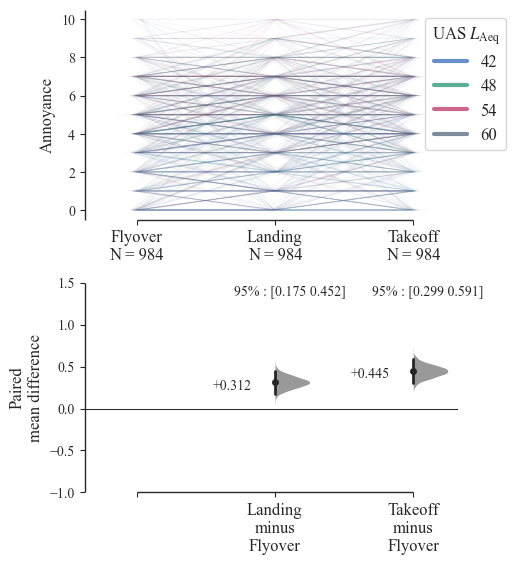

In [152]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                   contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                   slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                   custom_palette=mycolours, es_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                   contrast_show_es=True, es_sf=3,
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95% : " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAOpDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [42]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyby,Landing,984,984,Cohen's d,baseline,0.125200,95,0.069658,0.181372,0.0002,8.734782e-07,98564.0,1.366143e-05,-4.371361
1,Flyby,Takeoff,984,984,Cohen's d,baseline,0.177272,95,0.119462,0.235563,0.0002,1.466700e-09,99960.5,3.440872e-09,-5.963452


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\198372980.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAOpParkDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\198372980.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpParkDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\198372980.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpParkDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyover,Landing,492,492,mean difference,baseline,0.353659,95,0.160569,0.563008,0.0006,0.000191,24936.0,0.000730,-3.399509
1,Flyover,Takeoff,492,492,mean difference,baseline,0.430894,95,0.225610,0.638211,0.0002,0.000087,26950.5,0.000068,-4.017696


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


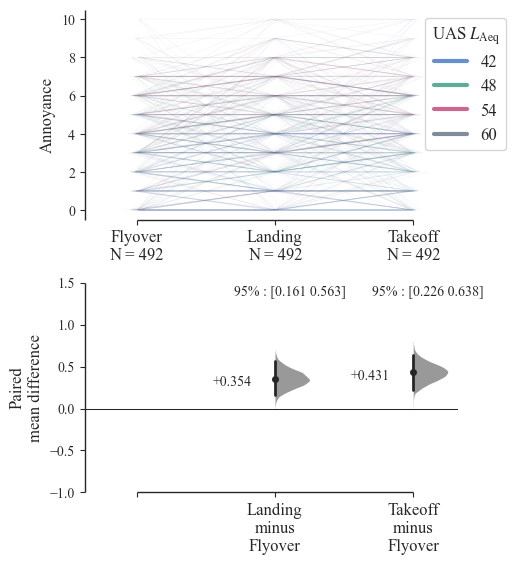

In [153]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataPkMD = dataPkloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                       slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours, es_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataPkloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95% : " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAOpParkDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpParkDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadBL.mean_diff.statistical_tests


In [44]:
out = pd.concat([out, dataPkloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadBL.cohens_d.statistical_tests])
dataPkloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyby,Landing,492,492,Cohen's d,baseline,0.143209,95,0.064627,0.227708,0.0006,0.000191,24936.0,0.000730,-3.399509
1,Flyby,Takeoff,492,492,Cohen's d,baseline,0.175236,95,0.092028,0.261328,0.0002,0.000087,26950.5,0.000068,-4.017696


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\778682501.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAOpStreetDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\778682501.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpStreetDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\778682501.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpStreetDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyover,Landing,492,492,mean difference,baseline,0.270325,95,0.077236,0.461382,0.004799,0.001284,24420.5,0.005928,-2.763793
1,Flyover,Takeoff,492,492,mean difference,baseline,0.459350,95,0.258130,0.668699,0.000200,0.000004,23199.0,0.000012,-4.419069


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


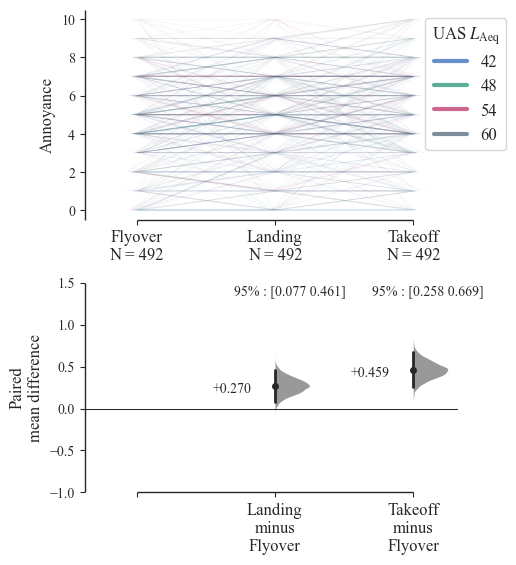

In [154]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataStMD = dataStloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                       slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours, es_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataStloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95% : " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAOpStreetDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpStreetDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataStMD;
dataStloadBL.mean_diff.statistical_tests


In [46]:
out = pd.concat([out, dataStloadBL.mean_diff.statistical_tests])    
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadBL.cohens_d.statistical_tests])
dataStloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyby,Landing,492,492,Cohen's d,baseline,0.110748,95,0.031931,0.189216,0.004799,0.001284,24420.5,0.005928,-2.763793
1,Flyby,Takeoff,492,492,Cohen's d,baseline,0.185207,95,0.103246,0.270884,0.000200,0.000004,23199.0,0.000012,-4.419069


In [ ]:
# assign data for processing
dataHiloadBL = dabest.load(data=data.loc[data['UASLAeq'] == '60'], idx=("Overflight", "Landing", "Takeoff"),
                           x='UASOperation', y='Annoyance', paired='baseline',
                           id_col='dummyID', resamples=5000, random_seed=808)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3732789966.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAOpHiDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3732789966.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpHiDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3732789966.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpHiDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyover,Landing,246,246,mean difference,baseline,0.333333,95,0.028455,0.626016,0.038192,0.009347,7363.0,0.035173,-2.118107
1,Flyover,Takeoff,246,246,mean difference,baseline,0.796748,95,0.495935,1.121951,0.000200,0.000003,6319.5,0.000001,-4.981410


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


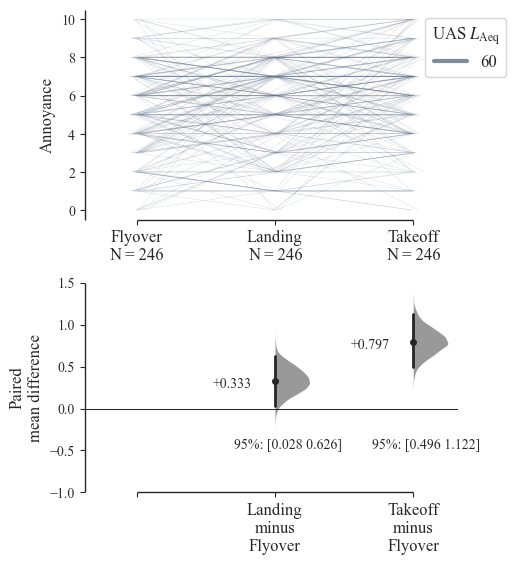

In [195]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(5.14, 3))
dataHiMD = dataHiloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                       slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours[3:], es_marker_size=4, contrast_ylim=(-1, 1.5), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataHiloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-12.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAOpHiDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAOpHiDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataHiMD;
dataHiloadBL.mean_diff.statistical_tests


In [49]:
out = pd.concat([out, dataHiloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataHiloadBL.cohens_d.statistical_tests])
dataHiloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,Flyby,Landing,246,246,Cohen's d,baseline,0.138743,95,0.011994,0.264158,0.038192,0.009347,7363.0,0.035173,-2.118107
1,Flyby,Takeoff,246,246,Cohen's d,baseline,0.328772,95,0.203651,0.463129,0.000200,0.000003,6319.5,0.000001,-4.981410


### UAS type and operation combined

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestA[~dataBySubjTestA['StimFile'].str.contains("PwrScale")]
data = data[data['UASType'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AmbientEnv', 'UASLAeq', 'UASType', 'UASOperation', 'Annoyance']]
data.sort_values(by=['AmbientEnv', 'ID', 'UASLAeq', 'UASType', 'UASOperation'], inplace=True)

# take highest LAeq in park env
dataPk = data.loc[(data['AmbientEnv'] == "Park"), :]
dataPk['UASTypeOp'] = dataPk['UASType'].astype(str) + " " + dataPk['UASOperation'].astype(str)
dataPk.sort_values(by=['ID', 'UASLAeq', 'UASTypeOp'], inplace=True)

# take highest LAeq in park env
dataSt = data.loc[(data['AmbientEnv'] == "Street"), :]
dataSt['UASTypeOp'] = dataSt['UASType'].astype(str) + " " + dataSt['UASOperation'].astype(str)
dataSt.sort_values(by=['ID', 'UASLAeq', 'UASTypeOp'], inplace=True)

# create a dummy pairing ID
data['UASTypeOp'] = data['UASType'].astype(str) + " " + data['UASOperation'].astype(str)
data.sort_values(by=['AmbientEnv', 'ID', 'UASLAeq', 'UASTypeOp'], inplace=True)

data['dummyID'] = np.repeat(np.arange(1, len(data['ID'])//len(data['UASTypeOp'].unique()) + 1, dtype=int), len(data['UASTypeOp'].unique()), axis=0)
dataPk['dummyID'] = np.repeat(np.arange(1, len(dataPk['ID'])//len(dataPk['UASTypeOp'].unique()) + 1, dtype=int), len(dataPk['UASTypeOp'].unique()), axis=0)
dataSt['dummyID'] = np.repeat(np.arange(1, len(dataSt['ID'])//len(dataSt['UASTypeOp'].unique()) + 1, dtype=int), len(dataSt['UASTypeOp'].unique()), axis=0)


In [ ]:
# assign data for processing

dataloadBL = dabest.load(data=data,  idx=("T150 Overflight", "M300 Overflight", "H520 Overflight",
                                          "T150 Landing", "M300 Landing", "H520 Landing",
                                          "T150 Takeoff", "M300 Takeoff", "H520 Takeoff"), x='UASTypeOp', y='Annoyance',
                         paired='baseline', id_col='dummyID', resamples=5000, random_seed=42828412)

dataPkloadBL = dabest.load(data=dataPk,  idx=("T150 Overflight", "M300 Overflight", "H520 Overflight",
                                              "T150 Landing", "M300 Landing", "H520 Landing",
                                              "T150 Takeoff", "M300 Takeoff", "H520 Takeoff"), x='UASTypeOp', y='Annoyance',
                           paired='baseline', id_col='dummyID', resamples=5000, random_seed=82108)
dataStloadBL = dabest.load(data=dataSt,  idx=("T150 Overflight", "M300 Overflight", "H520 Overflight",
                                              "T150 Landing", "M300 Landing", "H520 Landing",
                                              "T150 Takeoff", "M300 Takeoff", "H520 Takeoff"), x='UASTypeOp', y='Annoyance',
                           paired='baseline', id_col='dummyID', resamples=5000, random_seed=1198232)

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3491468307.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtATypeOpDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3491468307.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeOpDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3491468307.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeOpDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Flyover,M300 Flyover,328,328,mean difference,baseline,0.094512,95,-0.143293,0.317073,0.438112,1.659381e-01,10970.0,4.241502e-01,-0.800244
1,T150 Flyover,H520 Flyover,328,328,mean difference,baseline,0.323171,95,0.109756,0.542683,0.004199,2.803496e-03,10619.0,3.438486e-03,-2.947074
2,T150 Flyover,T150 Landing,328,328,mean difference,baseline,0.335366,95,0.067073,0.585366,0.009198,7.376186e-03,11421.5,1.140130e-02,-2.544547
3,T150 Flyover,M300 Landing,328,328,mean difference,baseline,0.393293,95,0.152439,0.621951,0.001000,3.304430e-04,11456.0,9.682409e-04,-3.329832
4,T150 Flyover,H520 Landing,328,328,mean difference,baseline,0.625000,95,0.375000,0.875000,0.000200,1.086049e-07,9182.5,1.814010e-06,-4.861293
5,T150 Flyover,T150 Takeoff,328,328,mean difference,baseline,0.414634,95,0.155488,0.667683,0.001800,7.971033e-04,11098.5,1.433034e-03,-3.215333
6,T150 Flyover,M300 Takeoff,328,328,mean difference,baseline,0.567073,95,0.323171,0.795732,0.000200,3.628993e-06,8409.0,5.337762e-06,-4.627711
7,T150 Flyover,H520 Takeoff,328,328,mean difference,baseline,0.771341,95,0.503049,1.027439,0.000200,1.918921e-08,10135.5,1.125239e-08,-5.860735


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


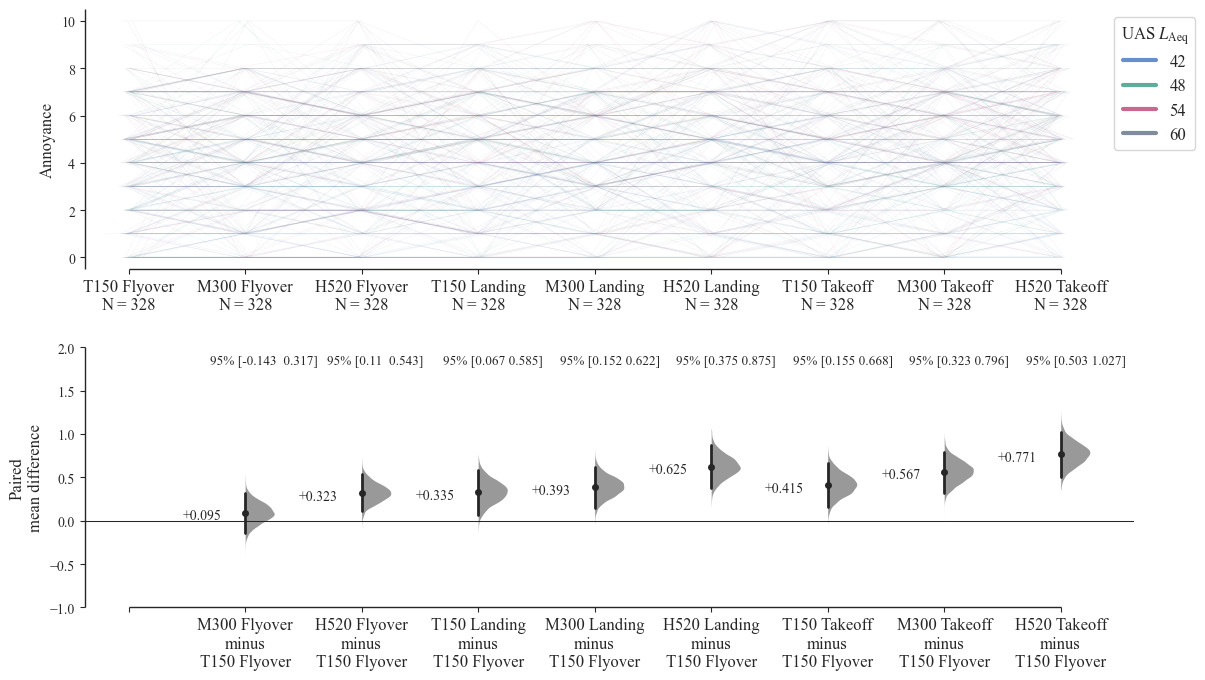

In [163]:
##### calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(12, 3.5))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                   contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                   slopegraph_xjitter=0.03, slopegraph_yjitter=0.0, jitter_seed=303,
                                   custom_palette=mycolours[0:4], es_marker_size=4, contrast_ylim=(-1, 2), float_contrast=True,
                                   contrast_show_es=True, es_sf=3,
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95% " + str(diffrow[1:]), fontsize=9.5)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtATypeOpDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtATypeOpDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [153]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Flyby,M300 Flyby,328,328,Cohen's d,baseline,0.038661,95,-0.056796,0.131360,0.438112,1.659381e-01,10970.0,4.241502e-01,-0.800244
1,T150 Flyby,H520 Flyby,328,328,Cohen's d,baseline,0.130648,95,0.045006,0.219179,0.004199,2.803496e-03,10619.0,3.438486e-03,-2.947074
2,T150 Flyby,T150 Landing,328,328,Cohen's d,baseline,0.136109,95,0.027418,0.240110,0.009198,7.376186e-03,11421.5,1.140130e-02,-2.544547
3,T150 Flyby,M300 Landing,328,328,Cohen's d,baseline,0.160460,95,0.062594,0.256846,0.001000,3.304430e-04,11456.0,9.682409e-04,-3.329832
4,T150 Flyby,H520 Landing,328,328,Cohen's d,baseline,0.249409,95,0.147416,0.352336,0.000200,1.086049e-07,9182.5,1.814010e-06,-4.861293
5,T150 Flyby,T150 Takeoff,328,328,Cohen's d,baseline,0.164140,95,0.062209,0.264266,0.001800,7.971033e-04,11098.5,1.433034e-03,-3.215333
6,T150 Flyby,M300 Takeoff,328,328,Cohen's d,baseline,0.229319,95,0.132053,0.324829,0.000200,3.628993e-06,8409.0,5.337762e-06,-4.627711
7,T150 Flyby,H520 Takeoff,328,328,Cohen's d,baseline,0.311304,95,0.203803,0.416670,0.000200,1.918921e-08,10135.5,1.125239e-08,-5.860735


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2897043986.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAPkTypeOpDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2897043986.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAPkTypeOpDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2897043986.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAPkTypeOpDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Flyover,M300 Flyover,164,164,mean difference,baseline,0.280488,95,-0.036585,0.615854,0.098180,7.661721e-02,2611.5,1.005645e-01,-1.651487
1,T150 Flyover,H520 Flyover,164,164,mean difference,baseline,0.451220,95,0.152439,0.792683,0.005199,9.464494e-03,2706.5,7.273684e-03,-2.718222
2,T150 Flyover,T150 Landing,164,164,mean difference,baseline,0.615854,95,0.280488,0.981707,0.000600,1.621305e-03,2542.0,8.799697e-04,-3.388928
3,T150 Flyover,M300 Landing,164,164,mean difference,baseline,0.359756,95,0.042683,0.670732,0.037592,2.308370e-02,3187.5,3.248925e-02,-2.156767
4,T150 Flyover,H520 Landing,164,164,mean difference,baseline,0.817073,95,0.451220,1.213415,0.000200,2.140203e-05,2232.5,5.024485e-05,-4.165546
5,T150 Flyover,T150 Takeoff,164,164,mean difference,baseline,0.359756,95,0.000000,0.756098,0.069386,9.349323e-02,3320.5,6.650658e-02,-1.847367
6,T150 Flyover,M300 Takeoff,164,164,mean difference,baseline,0.609756,95,0.286585,0.945122,0.000200,5.676448e-04,2424.0,4.015446e-04,-3.613871
7,T150 Flyover,H520 Takeoff,164,164,mean difference,baseline,1.054878,95,0.689024,1.420732,0.000200,5.238470e-07,2117.5,1.629070e-07,-5.474587


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


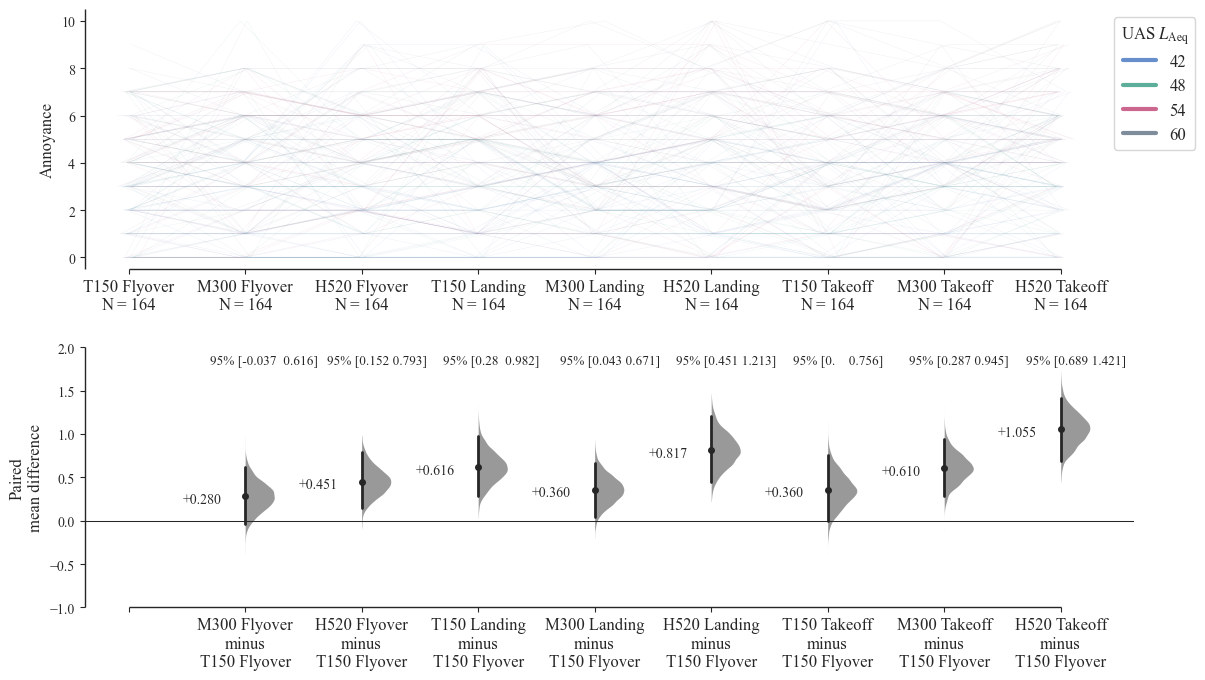

In [164]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(12, 3.5))
dataPkMD = dataPkloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                       slopegraph_xjitter=0.03, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours[0:4], es_marker_size=4, contrast_ylim=(-1, 2), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataPkloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95% " + str(diffrow[1:]), fontsize=9.5)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAPkTypeOpDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAPkTypeOpDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataPkMD;
dataPkloadBL.mean_diff.statistical_tests


In [155]:
out = pd.concat([out, dataPkloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataPkloadBL.cohens_d.statistical_tests])
dataPkloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Flyby,M300 Flyby,164,164,Cohen's d,baseline,0.118778,95,-0.015620,0.262608,0.098180,7.661721e-02,2611.5,1.005645e-01,-1.651487
1,T150 Flyby,H520 Flyby,164,164,Cohen's d,baseline,0.190719,95,0.064082,0.333781,0.005199,9.464494e-03,2706.5,7.273684e-03,-2.718222
2,T150 Flyby,T150 Landing,164,164,Cohen's d,baseline,0.255822,95,0.117895,0.408160,0.000600,1.621305e-03,2542.0,8.799697e-04,-3.388928
3,T150 Flyby,M300 Landing,164,164,Cohen's d,baseline,0.154951,95,0.019853,0.293825,0.037592,2.308370e-02,3187.5,3.248925e-02,-2.156767
4,T150 Flyby,H520 Landing,164,164,Cohen's d,baseline,0.326214,95,0.178402,0.478751,0.000200,2.140203e-05,2232.5,5.024485e-05,-4.165546
5,T150 Flyby,T150 Takeoff,164,164,Cohen's d,baseline,0.148812,95,0.002601,0.310356,0.069386,9.349323e-02,3320.5,6.650658e-02,-1.847367
6,T150 Flyby,M300 Takeoff,164,164,Cohen's d,baseline,0.260034,95,0.120406,0.401062,0.000200,5.676448e-04,2424.0,4.015446e-04,-3.613871
7,T150 Flyby,H520 Takeoff,164,164,Cohen's d,baseline,0.434757,95,0.283147,0.587144,0.000200,5.238470e-07,2117.5,1.629070e-07,-5.474587


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3959140938.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAStTypeOpDabest.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3959140938.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAStTypeOpDabest.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3959140938.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAStTypeOpDabest.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Flyover,M300 Flyover,164,164,mean difference,baseline,-0.091463,95,-0.445122,0.195122,0.601080,0.816491,2869.0,0.576389,0.559793
1,T150 Flyover,H520 Flyover,164,164,mean difference,baseline,0.195122,95,-0.097561,0.469512,0.186563,0.109890,2627.0,0.174730,-1.363102
2,T150 Flyover,T150 Landing,164,164,mean difference,baseline,0.054878,95,-0.329268,0.414634,0.749850,0.531751,3169.5,0.771865,-0.290419
3,T150 Flyover,M300 Landing,164,164,mean difference,baseline,0.426829,95,0.091463,0.737805,0.009798,0.005608,2597.5,0.011868,-2.544637
4,T150 Flyover,H520 Landing,164,164,mean difference,baseline,0.432927,95,0.085366,0.725610,0.006799,0.001047,2366.5,0.009739,-2.615754
5,T150 Flyover,T150 Takeoff,164,164,mean difference,baseline,0.469512,95,0.115854,0.780488,0.005199,0.001750,2275.5,0.006284,-2.768487
6,T150 Flyover,M300 Takeoff,164,164,mean difference,baseline,0.524390,95,0.164634,0.859756,0.003599,0.001730,1812.0,0.003729,-2.942669
7,T150 Flyover,H520 Takeoff,164,164,mean difference,baseline,0.487805,95,0.134146,0.817073,0.005399,0.004959,3016.5,0.006565,-2.753513


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


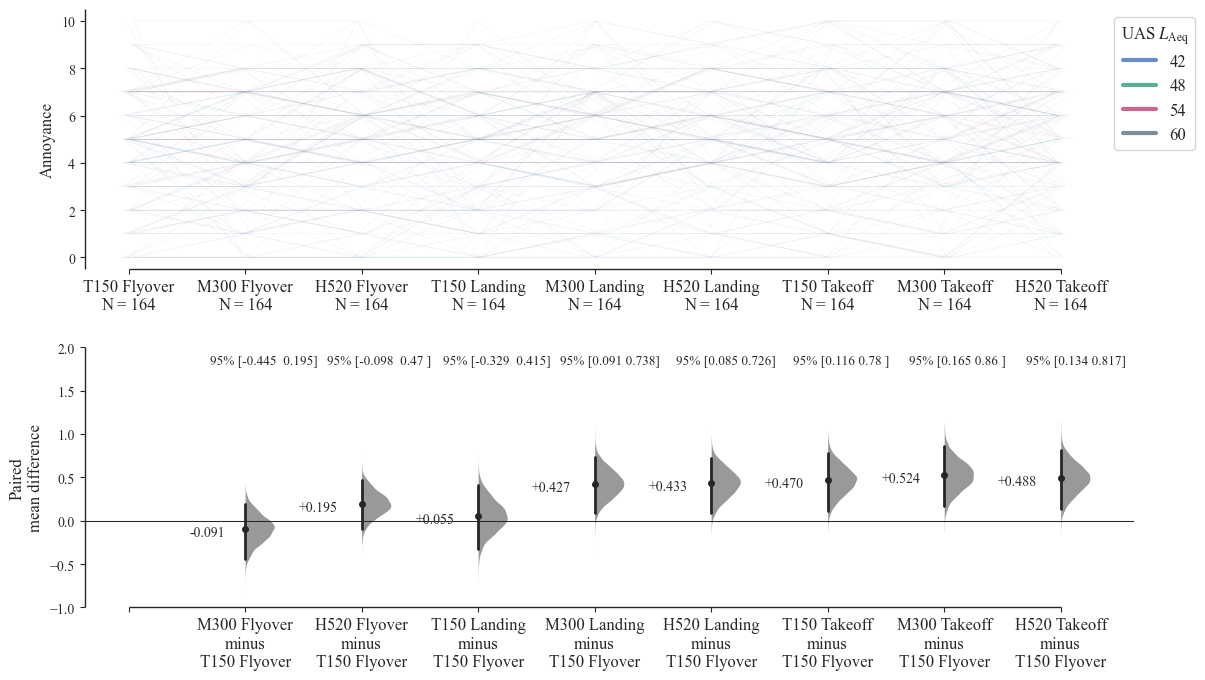

In [165]:
# calculate effect sizes and plot
fig, ax = plt.subplots(figsize=(12, 3.5))
dataStMD = dataStloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.125},
                                       slopegraph_xjitter=0.03, slopegraph_yjitter=0.0, jitter_seed=303,
                                       custom_palette=mycolours[0:4], es_marker_size=4, contrast_ylim=(-1, 2), float_contrast=True,
                                       contrast_show_es=True, es_sf=3,
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)
diffs = np.round(dataStloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-3.4, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95% " + str(diffrow[1:]), fontsize=9.5)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAStTypeOpDabest.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAStTypeOpDabest.pdf"),
                format='pdf', bbox_inches='tight')

dataStMD;
dataStloadBL.mean_diff.statistical_tests


In [57]:
out = pd.concat([out, dataStloadBL.mean_diff.statistical_tests])
# calculate effect sizes - Cohen's d
outd = pd.concat([outd, dataStloadBL.cohens_d.statistical_tests])
dataStloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,T150 Flyby,M300 Flyby,164,164,Cohen's d,baseline,-0.037464,95,-0.175467,0.084212,0.601080,0.816491,2869.0,0.576389,0.559793
1,T150 Flyby,H520 Flyby,164,164,Cohen's d,baseline,0.078499,95,-0.036357,0.194062,0.186563,0.109890,2627.0,0.174730,-1.363102
2,T150 Flyby,T150 Landing,164,164,Cohen's d,baseline,0.022416,95,-0.129394,0.173453,0.749850,0.531751,3169.5,0.771865,-0.290419
3,T150 Flyby,M300 Landing,164,164,Cohen's d,baseline,0.174305,95,0.038392,0.307535,0.009798,0.005608,2597.5,0.011868,-2.544637
4,T150 Flyby,H520 Landing,164,164,Cohen's d,baseline,0.178591,95,0.034155,0.305119,0.006799,0.001047,2366.5,0.009739,-2.615754
5,T150 Flyby,T150 Takeoff,164,164,Cohen's d,baseline,0.187563,95,0.046619,0.314040,0.005199,0.001750,2275.5,0.006284,-2.768487
6,T150 Flyby,M300 Takeoff,164,164,Cohen's d,baseline,0.210793,95,0.065597,0.348282,0.003599,0.001730,1812.0,0.003729,-2.942669
7,T150 Flyby,H520 Takeoff,164,164,Cohen's d,baseline,0.198481,95,0.055283,0.336951,0.005399,0.004959,3016.5,0.006565,-2.753513


### AAM attitude

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestA
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'AAM_attitude', 'Annoyance']]


In [59]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Supportive', 'Ambivalent', 'Concerned', 'Neutral'],
                         x='AAM_attitude', y='Annoyance', resamples=5000, random_seed=3616)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1846013393.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAAttDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1846013393.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAAttDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1846013393.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAAttDabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,858,624,mean difference,None,0.592803,95,0.337995,0.836976,0.0002,3.290390e-06,-4.670084,5.770857e-06,-4.551185,6.710828e-06,231324.5
1,Supportive,Concerned,858,546,mean difference,None,0.632867,95,0.375458,0.884449,0.0002,1.664511e-06,-4.812701,3.755363e-06,-4.643006,2.476898e-06,199573.5
2,Supportive,Neutral,858,1170,mean difference,None,1.328594,95,1.110101,1.559907,0.0002,2.859394e-29,-11.433174,8.979513e-30,-11.516742,2.317014e-26,364345.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


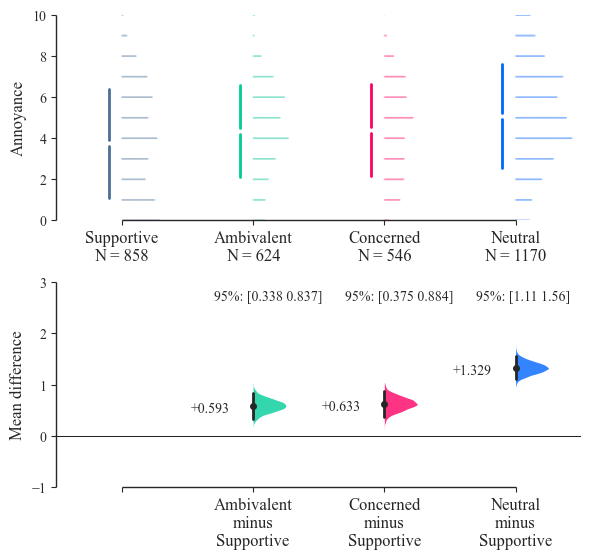

In [60]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.005,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Neutral': mycolours[0],
                                                   'Ambivalent': mycolours[1],
                                                   'Concerned': mycolours[2],
                                                   'Supportive': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-1, 3),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAAttDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAAttDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [61]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,858,624,Cohen's d,None,0.239449,95,0.135367,0.339727,0.0002,3.290390e-06,-4.670084,5.770857e-06,-4.551185,6.710828e-06,231324.5
1,Supportive,Concerned,858,546,Cohen's d,None,0.254181,95,0.150671,0.357394,0.0002,1.664511e-06,-4.812701,3.755363e-06,-4.643006,2.476898e-06,199573.5
2,Supportive,Neutral,858,1170,Cohen's d,None,0.517639,95,0.429056,0.607492,0.0002,2.859394e-29,-11.433174,8.979513e-30,-11.516742,2.317014e-26,364345.5


### Home residence area

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestA
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'Home_Area', 'Annoyance']]


In [63]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Urban', 'Suburban', 'Rural'],
                         x='Home_Area', y='Annoyance', resamples=5000, random_seed=80842)


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\dabest-2024.3.29-py3.10.egg\dabest\plot_tools.py:1232: UserWarning: 0.3% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\3626896185.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtAAORDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\3626896185.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtAAORDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\3626896185.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes 

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2106,1014,mean difference,None,0.706370,95,0.527175,0.872197,0.000200,1.896505e-15,-8.000883,1.340707e-13,-7.435315,1.954577e-11,910678.5
1,Urban,Rural,2106,78,mean difference,None,-0.519468,95,-1.025641,0.054606,0.081984,6.488741e-02,1.870556,8.685535e-02,1.712996,7.266550e-02,91893.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


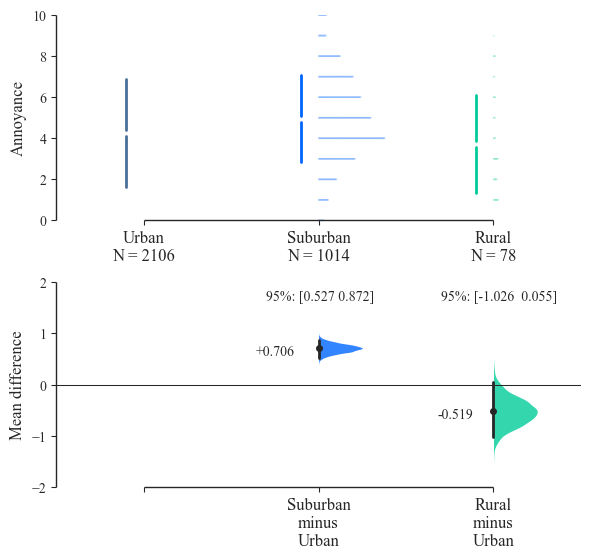

In [64]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.005,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Suburban': mycolours[0],
                                                   'Rural': mycolours[1],
                                                   'Urban': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 2),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtAAORDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtAAORDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [65]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2106,1014,Cohen's d,None,0.284203,95,0.210467,0.351086,0.000200,1.896505e-15,-8.000883,1.340707e-13,-7.435315,1.954577e-11,910678.5
1,Urban,Rural,2106,78,Cohen's d,None,-0.197518,95,-0.390260,0.021140,0.081984,6.488741e-02,1.870556,8.685535e-02,1.712996,7.266550e-02,91893.5


## Part B

### Number of events

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestB
data = data[data['UASLAeq'] != "Baseline"]
data['UASEvents'] = data['UASEvents'].astype(int).astype(str)
data = data.loc[:, ['ID', 'StimFile', 'UASEvents', 'UASLAeq', 'UASType', 'Annoyance']]
data.sort_values(by=['ID', 'UASType', 'UASLAeq', 'UASEvents'], inplace=True)

dataLo = data.loc[data['UASLAeq'] == "54", :]
dataHi = data.loc[data['UASLAeq'] == "60", :]
dataH520 = data.loc[data['UASType'] == "H520", :]
dataT150 = data.loc[data['UASType'] == "T150", :]
dataLoH520 = data.loc[(data['UASType'] == "H520") & (data['UASLAeq'] == "54"), :]
dataLoT150 = data.loc[(data['UASType'] == "T150") & (data['UASLAeq'] == "54"), :]
dataHiH520 = data.loc[(data['UASType'] == "H520") & (data['UASLAeq'] == "60"), :]
dataHiT150 = data.loc[(data['UASType'] == "T150") & (data['UASLAeq'] == "60"), :]

# create dummy pairing IDs
for dataset in [data, dataLo, dataHi, dataH520, dataT150, dataLoH520, dataLoT150, dataHiH520, dataHiT150]:
    dataset['dummyID'] = np.repeat(np.arange(1, len(dataset['ID'])//len(dataset['UASEvents'].unique()) + 1, dtype=int), len(dataset['UASEvents'].unique()), axis=0)


In [201]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=data['UASEvents'].unique(),
                         x='UASEvents', y='Annoyance', paired='baseline',
                         id_col='dummyID', resamples=5000, random_seed=888)
dataloadSQ = dabest.load(data=data, idx=data['UASEvents'].unique(),
                         x='UASEvents', y='Annoyance', paired='sequential',
                         id_col='dummyID', resamples=5000, random_seed=456)

dataLoloadBL = dabest.load(data=dataLo, idx=dataLo['UASEvents'].unique(),
                           x='UASEvents', y='Annoyance', paired='baseline',
                           id_col='dummyID', resamples=5000, random_seed=4373)

dataLoloadSQ = dabest.load(data=dataLo, idx=dataLo['UASEvents'].unique(),
                           x='UASEvents', y='Annoyance', paired='sequential',
                           id_col='dummyID', resamples=5000, random_seed=714)

dataHiloadSQ = dabest.load(data=dataHi, idx=dataHi['UASEvents'].unique(),
                           x='UASEvents', y='Annoyance', paired='sequential',
                           id_col='dummyID', resamples=5000, random_seed=99595)

dataH520loadSQ = dabest.load(data=dataH520, idx=dataH520['UASEvents'].unique(),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', resamples=5000, random_seed=8484984)

dataT150loadSQ = dabest.load(data=dataT150, idx=dataT150['UASEvents'].unique(),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', resamples=5000, random_seed=2313)

dataLoH520loadSQ = dabest.load(data=dataLoH520, idx=dataLoH520['UASEvents'].unique(),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', resamples=5000, random_seed=15619)

dataHiH520loadSQ = dabest.load(data=dataHiH520, idx=dataHiH520['UASEvents'].unique(),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', resamples=5000, random_seed=503)

dataLoT150loadSQ = dabest.load(data=dataLoT150, idx=dataLoT150['UASEvents'].unique(),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', resamples=5000, random_seed=4025498)

dataHiT150loadSQ = dabest.load(data=dataHiT150, idx=dataHiT150['UASEvents'].unique(),
                               x='UASEvents', y='Annoyance', paired='sequential',
                               id_col='dummyID', resamples=5000, random_seed=117)

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3784917603.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtBDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3784917603.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3784917603.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBDabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,168,168,mean difference,baseline,0.976190,95,0.660714,1.285714,0.0002,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,1,5,168,168,mean difference,baseline,1.273810,95,0.946429,1.607143,0.0002,2.049133e-11,1600.0,1.497806e-12,-7.652331
2,1,9,168,168,mean difference,baseline,1.410714,95,1.029762,1.773810,0.0002,1.248546e-10,2095.5,1.546221e-11,-7.241797


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


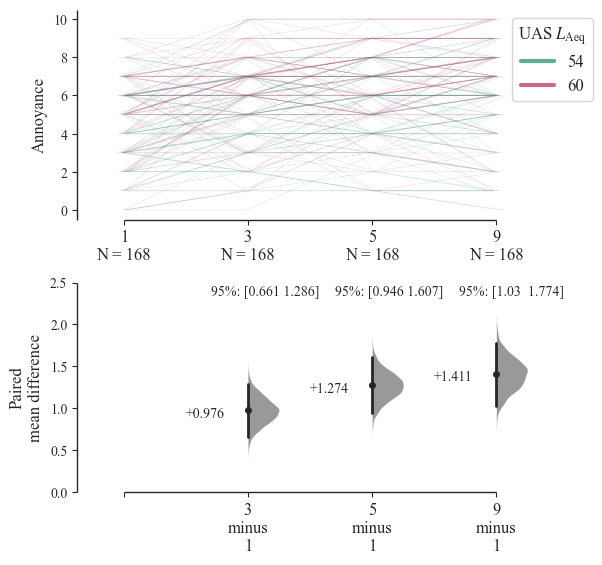

In [172]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                   contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                   slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette=mycolours[1:3], es_marker_size=4, contrast_ylim=(0, 2.5),
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtBDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtBDabestBase.pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [69]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,168,168,Cohen's d,baseline,0.447704,95,0.302082,0.602362,0.0002,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,1,5,168,168,Cohen's d,baseline,0.589221,95,0.435660,0.750909,0.0002,2.049133e-11,1600.0,1.497806e-12,-7.652331
2,1,9,168,168,Cohen's d,baseline,0.602227,95,0.437218,0.778378,0.0002,1.248546e-10,2095.5,1.546221e-11,-7.241797


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2240889615.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtBDabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2240889615.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBDabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\2240889615.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBDabestSeq.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,168,168,mean difference,sequential,0.976190,95,0.660714,1.285714,0.000200,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,3,5,168,168,mean difference,sequential,0.297619,95,0.011905,0.547619,0.034793,1.094919e-02,2726.5,3.716497e-02,-2.100746
2,5,9,168,168,mean difference,sequential,0.136905,95,-0.101190,0.351190,0.218956,1.185307e-01,2741.5,2.422649e-01,-1.173503


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


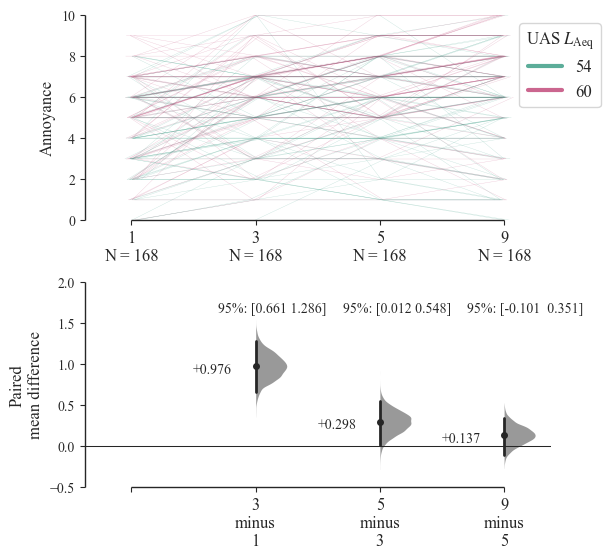

In [173]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadSQ.mean_diff.plot(swarm_ylim=(0, 10), color_col='UASLAeq',
                                   contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                   slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette=mycolours[1:3], es_marker_size=4, contrast_ylim=(-0.5, 2),
                                   legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                  'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)
    
if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtBDabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtBDabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadSQ.mean_diff.statistical_tests


In [71]:
out = pd.concat([out, dataloadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadSQ.cohens_d.statistical_tests])
dataloadSQ.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,168,168,Cohen's d,sequential,0.447704,95,0.299316,0.599291,0.000200,3.991841e-08,1996.5,1.219659e-08,-5.994994
1,3,5,168,168,Cohen's d,sequential,0.137169,95,0.007897,0.259204,0.034793,1.094919e-02,2726.5,3.716497e-02,-2.100746
2,5,9,168,168,Cohen's d,sequential,0.058694,95,-0.038827,0.158758,0.218956,1.185307e-01,2741.5,2.422649e-01,-1.173503


#### Segregated by LAeq

##### 54 dB

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3445389863.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB54DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3445389863.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB54DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\3445389863.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB54DabestSeq.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,mean difference,sequential,0.821429,95,0.416667,1.202381,0.000400,0.000180,489.5,0.000131,-4.011605
1,3,5,84,84,mean difference,sequential,0.345238,95,-0.083333,0.678571,0.090782,0.025336,640.0,0.084735,-1.744719
2,5,9,84,84,mean difference,sequential,-0.154762,95,-0.511905,0.142857,0.392921,0.571022,730.5,0.357431,0.925420


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


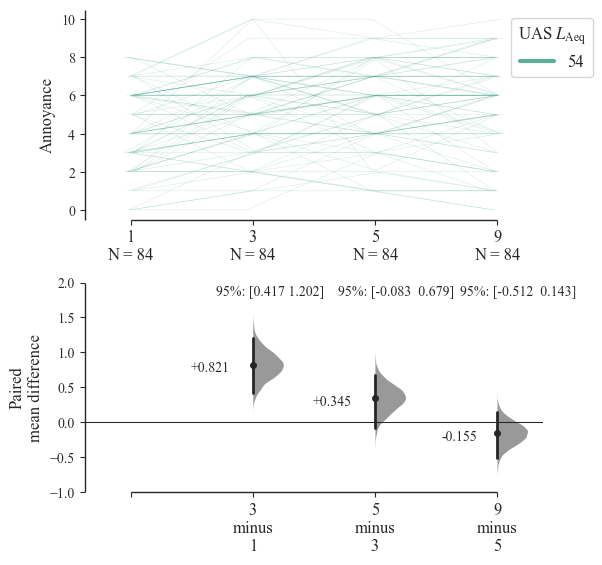

In [176]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataLoMD = dataLoloadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                       slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                       contrast_show_es=True, es_sf=3,
                                       custom_palette=mycolours[1:], es_marker_size=4, contrast_ylim=(-1, 2),
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataLoloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB54DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB54DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataLoMD;
dataLoloadSQ.mean_diff.statistical_tests


In [75]:
out = pd.concat([out, dataLoloadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataLoloadSQ.cohens_d.statistical_tests])
dataLoloadSQ.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,Cohen's d,sequential,0.384312,95,0.199143,0.582215,0.000400,0.000180,489.5,0.000131,-4.011605
1,3,5,84,84,Cohen's d,sequential,0.159297,95,-0.036339,0.328584,0.090782,0.025336,640.0,0.084735,-1.744719
2,5,9,84,84,Cohen's d,sequential,-0.066582,95,-0.216386,0.066528,0.392921,0.571022,730.5,0.357431,0.925420


##### 60 dB

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\4100757785.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB60DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\4100757785.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB60DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\4100757785.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB60DabestSeq.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,mean difference,sequential,1.130952,95,0.630952,1.595238,0.000200,0.000061,521.5,0.000025,-4.463727
1,3,5,84,84,mean difference,sequential,0.250000,95,-0.178571,0.630952,0.197960,0.158162,727.5,0.223543,-1.226329
2,5,9,84,84,mean difference,sequential,0.428571,95,0.107143,0.726190,0.010598,0.005573,508.0,0.007861,-2.724065


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


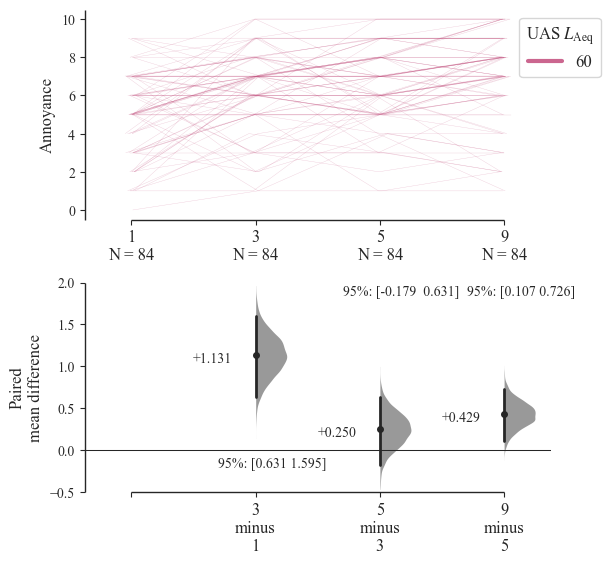

In [178]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataHiMD = dataHiloadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                       contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                       slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                       contrast_show_es=True, es_sf=3,
                                       custom_palette=mycolours[2:], es_marker_size=4, contrast_ylim=(-0.5, 2),
                                       legend_kwargs={'loc': 'upper center', 'title': r"UAS $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                      'frameon': True, 'title_fontsize': 12}, ax=ax)


diffs = np.round(dataHiloadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    if ii == 0:
        ax.text(x=0.7 + ii, y=-13.5, s="95%: " + str(diffrow[1:]), fontsize=10)
    else:
        ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB60DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB60DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataHiMD;
dataHiloadSQ.mean_diff.statistical_tests


In [79]:
out = pd.concat([out, dataHiloadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataHiloadSQ.cohens_d.statistical_tests])
dataHiloadSQ.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,Cohen's d,sequential,0.530258,95,0.282600,0.772443,0.000200,0.000061,521.5,0.000025,-4.463727
1,3,5,84,84,Cohen's d,sequential,0.121538,95,-0.084457,0.316311,0.198160,0.158162,727.5,0.223543,-1.226329
2,5,9,84,84,Cohen's d,sequential,0.198268,95,0.050433,0.355630,0.010598,0.005573,508.0,0.007861,-2.724065


#### Segregated by UAS LAeq and type

##### 54 dB, H520

C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1342750018.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB54H520DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1342750018.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB54H520DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1342750018.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be m

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,mean difference,sequential,0.619048,95,0.047619,1.095238,0.023795,0.019461,121.5,0.027277,-2.289389
1,3,5,42,42,mean difference,sequential,0.523810,95,0.047619,0.952381,0.022795,0.033926,142.0,0.030835,-2.236293
2,5,9,42,42,mean difference,sequential,0.000000,95,-0.428571,0.380952,0.912418,0.890156,226.0,1.000000,0.000000


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


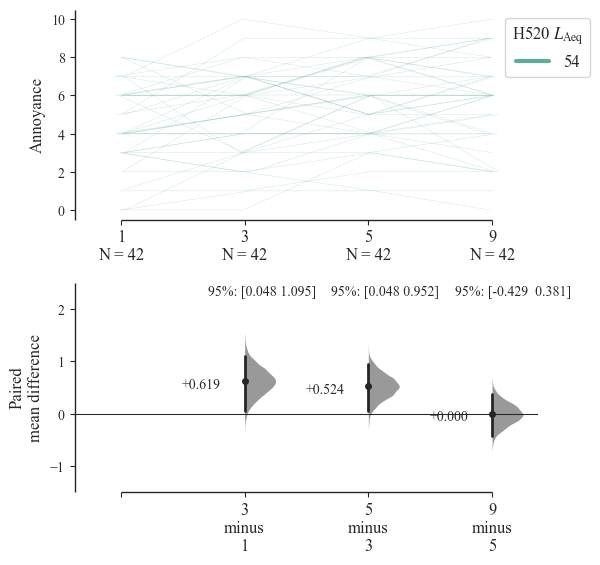

In [180]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataLoH520MD = dataLoH520loadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                               slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[1:], es_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"H520 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataLoH520loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB54H520DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB54H520DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataLoH520MD;
dataLoH520loadSQ.mean_diff.statistical_tests


In [83]:
out = pd.concat([out, dataLoH520loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataLoH520loadSQ.cohens_d.statistical_tests])
dataLoH520loadSQ.cohens_d.statistical_tests


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,Cohen's d,sequential,0.275474,95,0.032248,0.516894,0.023795,0.019461,121.5,0.027277,-2.289389
1,3,5,42,42,Cohen's d,sequential,0.238503,95,0.029578,0.457933,0.022795,0.033926,142.0,0.030835,-2.236293
2,5,9,42,42,Cohen's d,sequential,0.000000,95,-0.192840,0.174945,0.912418,0.890156,226.0,1.000000,0.000000


##### 60 dB, H520

C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\89106909.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB60H520DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\89106909.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB60H520DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\89106909.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made la

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,mean difference,sequential,1.023810,95,0.285714,1.666667,0.008598,0.010268,148.5,0.006226,-2.884229
1,3,5,42,42,mean difference,sequential,0.309524,95,-0.309524,0.880952,0.283743,0.315645,225.5,0.320260,-1.006117
2,5,9,42,42,mean difference,sequential,0.547619,95,0.166667,0.928571,0.005199,0.007245,80.5,0.007146,-2.831628


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


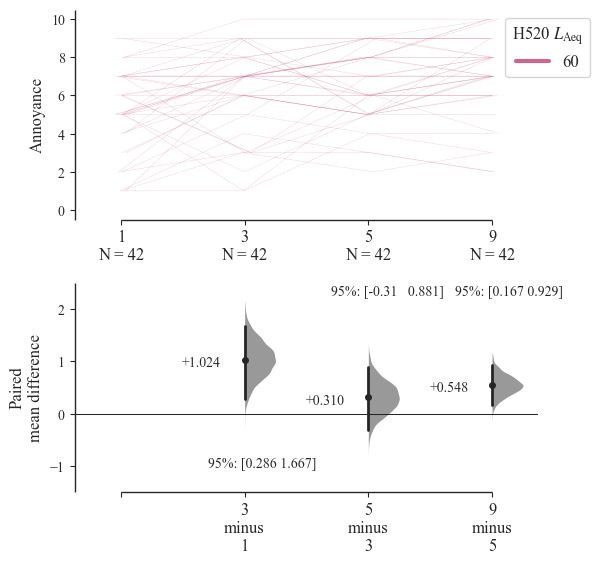

In [182]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataHiH520MD = dataHiH520loadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                               slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[2:], es_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"H520 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataHiH520loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    if ii == 0:
        ax.text(x=0.7 + ii, y=-13.5, s="95%: " + str(diffrow[1:]), fontsize=10)
    else:
        ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB60H520DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB60H520DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataHiH520MD;
dataHiH520loadSQ.mean_diff.statistical_tests


In [87]:
out = pd.concat([out, dataHiH520loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataHiH520loadSQ.cohens_d.statistical_tests])
dataHiH520loadSQ.cohens_d.statistical_tests


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,Cohen's d,sequential,0.458114,95,0.119275,0.794117,0.008798,0.010268,148.5,0.006226,-2.884229
1,3,5,42,42,Cohen's d,sequential,0.147816,95,-0.148997,0.419511,0.283743,0.315645,225.5,0.320260,-1.006117
2,5,9,42,42,Cohen's d,sequential,0.271639,95,0.075423,0.509602,0.005199,0.007245,80.5,0.007146,-2.831628


##### 54 dB, T150

C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\650381005.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB54T150DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\650381005.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB54T150DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\650381005.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,mean difference,sequential,1.023810,95,0.428571,1.619048,0.003199,0.003138,127.0,0.001855,-3.327926
1,3,5,42,42,mean difference,sequential,0.166667,95,-0.571429,0.666667,0.568886,0.285736,181.5,0.604774,-0.521573
2,5,9,42,42,mean difference,sequential,-0.309524,95,-0.857143,0.119048,0.202360,0.329206,138.0,0.237850,1.197862


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


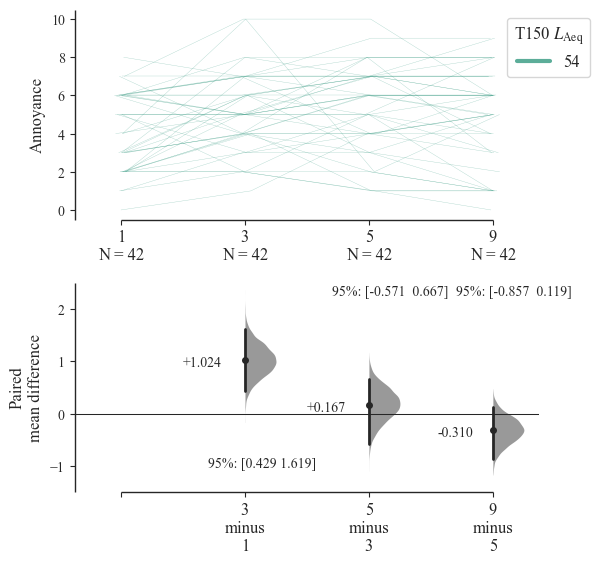

In [184]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataLoT150MD = dataLoT150loadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45},
                                               slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[1:], es_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"T150 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataLoT150loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    if ii == 0:
        ax.text(x=0.7 + ii, y=-13.5, s="95%: " + str(diffrow[1:]), fontsize=10)
    else:
        ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB54T150DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB54T150DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataLoT150MD;
dataLoT150loadSQ.mean_diff.statistical_tests


In [91]:
out = pd.concat([out, dataLoT150loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataLoT150loadSQ.cohens_d.statistical_tests])
dataLoT150loadSQ.cohens_d.statistical_tests


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,Cohen's d,sequential,0.501650,95,0.217694,0.806379,0.003199,0.003138,127.0,0.001855,-3.327926
1,3,5,42,42,Cohen's d,sequential,0.077207,95,-0.246645,0.337045,0.568886,0.285736,181.5,0.604774,-0.521573
2,5,9,42,42,Cohen's d,sequential,-0.131116,95,-0.355194,0.065223,0.202360,0.329206,138.0,0.237850,1.197862


##### 60 dB, T150

C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1519604368.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB60T150DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1519604368.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB60T150DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1519604368.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be m

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,mean difference,sequential,1.238095,95,0.500000,1.904762,0.001200,0.002227,120.0,0.001554,-3.390523
1,3,5,42,42,mean difference,sequential,0.190476,95,-0.380952,0.666667,0.540292,0.307765,147.5,0.486131,-0.702834
2,5,9,42,42,mean difference,sequential,0.309524,95,-0.214286,0.761905,0.186763,0.173164,180.5,0.221351,-1.241844


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


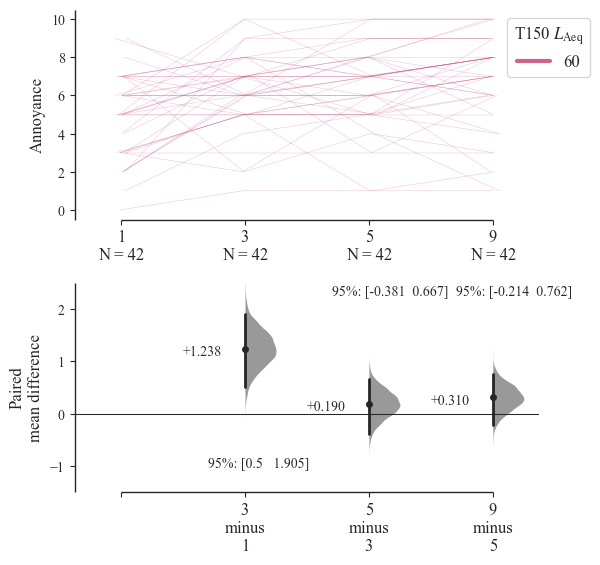

In [186]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataHiT150MD = dataHiT150loadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.45},
                                               slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[2:], es_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"T150 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)


diffs = np.round(dataHiT150loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    if ii == 0:
        ax.text(x=0.7 + ii, y=-13.5, s="95%: " + str(diffrow[1:]), fontsize=10)
    else:
        ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)
    
lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB60T150DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB60T150DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataHiT150MD;
dataHiT150loadSQ.mean_diff.statistical_tests


In [95]:
out = pd.concat([out, dataHiT150loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataHiT150loadSQ.cohens_d.statistical_tests])
dataHiT150loadSQ.cohens_d.statistical_tests


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\scipy\stats\_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,42,42,Cohen's d,sequential,0.604145,95,0.219027,0.962721,0.001200,0.002227,120.0,0.001554,-3.390523
1,3,5,42,42,Cohen's d,sequential,0.093217,95,-0.179928,0.352837,0.540292,0.307765,147.5,0.486131,-0.702834
2,5,9,42,42,Cohen's d,sequential,0.133791,95,-0.081875,0.366395,0.186763,0.173164,180.5,0.221351,-1.241844


#### Segregated by UAS type

##### H520

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\574294570.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtBH520DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\574294570.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBH520DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\574294570.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBH520DabestSeq.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,mean difference,sequential,0.821429,95,0.369048,1.238095,0.000600,0.000474,523.5,0.000406,-3.685605
1,3,5,84,84,mean difference,sequential,0.416667,95,0.023810,0.773810,0.029394,0.029518,721.0,0.033319,-2.164249
2,5,9,84,84,mean difference,sequential,0.273810,95,-0.023810,0.535714,0.054389,0.048482,586.0,0.064330,-1.874858


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


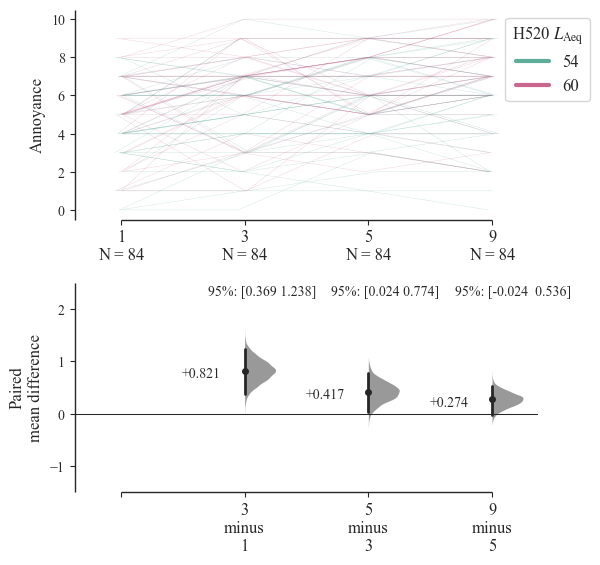

In [202]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataH520MD = dataH520loadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                               slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[1:], es_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"H520 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataH520loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtBH520DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtBH520DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataH520MD;
dataH520loadSQ.mean_diff.statistical_tests


In [205]:
out = pd.concat([out, dataH520loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataH520loadSQ.cohens_d.statistical_tests])
dataH520loadSQ.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,Cohen's d,sequential,0.360753,95,0.163308,0.559436,0.000600,0.000474,523.5,0.000406,-3.685605
1,3,5,84,84,Cohen's d,sequential,0.189972,95,0.016952,0.357130,0.029394,0.029518,721.0,0.033319,-2.164249
2,5,9,84,84,Cohen's d,sequential,0.122855,95,-0.005185,0.261085,0.054389,0.048482,586.0,0.064330,-1.874858


##### T150

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\36257375.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtBT150DabestSeq.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\36257375.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBT150DabestSeq.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\36257375.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBT150DabestSeq.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,mean difference,sequential,1.130952,95,0.666667,1.583333,0.000200,0.000021,484.0,0.000008,-4.760119
1,3,5,84,84,mean difference,sequential,0.178571,95,-0.285714,0.547619,0.366727,0.152560,650.0,0.393614,-0.857544
2,5,9,84,84,mean difference,sequential,0.000000,95,-0.380952,0.321429,0.945011,0.765591,790.0,1.000000,0.000000


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


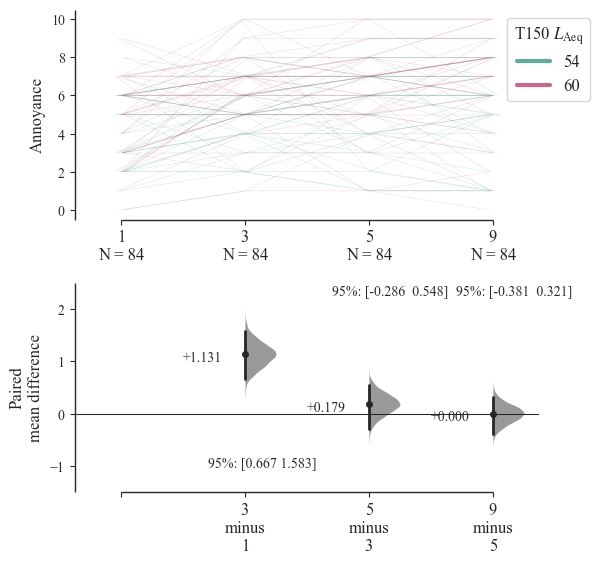

In [204]:
# calculate sequential paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataT150MD = dataT150loadSQ.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASLAeq',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.3},
                                               slopegraph_xjitter=0.02, slopegraph_yjitter=0.0, jitter_seed=303,
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[1:], es_marker_size=4, contrast_ylim=(-1.5, 2.5),
                                               legend_kwargs={'loc': 'upper center', 'title': r"T150 $L_\mathrm{Aeq}$", 'fontsize': 12,
                                                              'frameon': True, 'title_fontsize': 12}, ax=ax)

diffs = np.round(dataT150loadSQ.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    if ii == 0:
        ax.text(x=0.7 + ii, y=-13.5, s="95%: " + str(diffrow[1:]), fontsize=10)
    else:
        ax.text(x=0.7 + ii, y=-4.5, s="95%: " + str(diffrow[1:]), fontsize=10)

lgd = ax.get_legend()
for lh in lgd.legendHandles:
    lh.set_alpha(0.8)
    lh.set_linewidth(3)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtBT150DabestSeq.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtBT150DabestSeq.pdf"),
                format='pdf', bbox_inches='tight')

dataT150MD;
dataT150loadSQ.mean_diff.statistical_tests


In [206]:
out = pd.concat([out, dataT150loadSQ.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataT150loadSQ.cohens_d.statistical_tests])
dataT150loadSQ.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,1,3,84,84,Cohen's d,sequential,0.541703,95,0.318940,0.782269,0.000200,0.000021,484.0,0.000008,-4.760119
1,3,5,84,84,Cohen's d,sequential,0.082824,95,-0.127441,0.267629,0.366727,0.152560,650.0,0.393614,-0.857544
2,5,9,84,84,Cohen's d,sequential,0.000000,95,-0.154558,0.138552,0.945011,0.765591,790.0,1.000000,0.000000


### AAM attitude

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestB
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'AAM_attitude', 'Annoyance']]

# separate by level
dataLo = data.loc[data['UASLAeq'] == "54", :]
dataHi = data.loc[data['UASLAeq'] == "60", :]


In [97]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Supportive', 'Ambivalent', 'Concerned', 'Neutral'],
                         x='AAM_attitude', y='Annoyance', resamples=5000, random_seed=24624)

dataLoloadBL = dabest.load(data=dataLo, idx=['Supportive', 'Ambivalent', 'Concerned', 'Neutral'],
                           x='AAM_attitude', y='Annoyance', resamples=5000, random_seed=8478)

dataHiloadBL = dabest.load(data=dataHi, idx=['Supportive', 'Ambivalent', 'Concerned', 'Neutral'],
                           x='AAM_attitude', y='Annoyance', resamples=5000, random_seed=13)


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\dabest-2024.3.29-py3.10.egg\dabest\plot_tools.py:1232: UserWarning: 1.2% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1280261273.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtBAttDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1280261273.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBAttDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1280261273.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes 

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,176,144,mean difference,None,1.591540,95,1.145202,2.049242,0.000200,3.743899e-11,-6.860482,1.532014e-10,-6.619582,4.089515e-09,7875.5
1,Supportive,Concerned,176,112,mean difference,None,0.780032,95,0.200487,1.386364,0.010798,1.050531e-02,-2.579852,9.810589e-03,-2.599856,1.675580e-02,8220.0
2,Supportive,Neutral,176,240,mean difference,None,1.394318,95,0.933712,1.842424,0.000200,5.657951e-09,-5.973261,2.956642e-09,-6.066222,2.187909e-08,14390.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


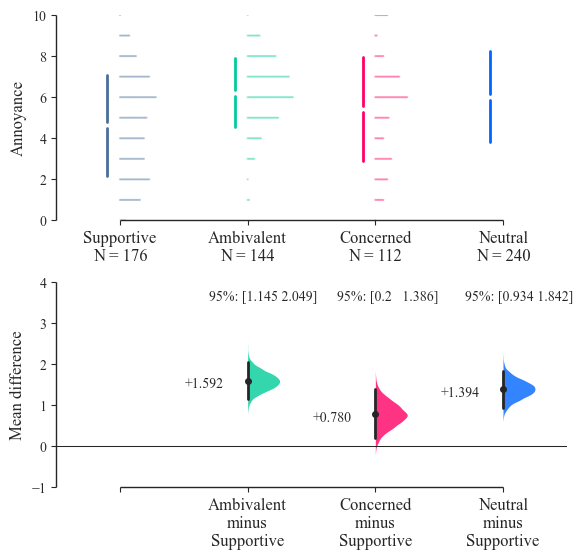

In [98]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.1,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Neutral': mycolours[0],
                                                   'Ambivalent': mycolours[1],
                                                   'Concerned': mycolours[2],
                                                   'Supportive': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-1, 4),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtBAttDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtBAttDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [99]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,176,144,Cohen's d,None,0.743820,95,0.528476,0.960925,0.000200,3.743899e-11,-6.860482,1.532014e-10,-6.619582,4.089515e-09,7875.5
1,Supportive,Concerned,176,112,Cohen's d,None,0.314254,95,0.077253,0.555377,0.010798,1.050531e-02,-2.579852,9.810589e-03,-2.599856,1.675580e-02,8220.0
2,Supportive,Neutral,176,240,Cohen's d,None,0.602009,95,0.396274,0.809763,0.000200,5.657951e-09,-5.973261,2.956642e-09,-6.066222,2.187909e-08,14390.5


C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1013720586.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB54AttDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1013720586.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB54AttDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1013720586.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB54AttDabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,88,72,mean difference,None,1.608586,95,0.981061,2.236111,0.000200,1.142550e-06,-5.064073,2.207513e-06,-4.914543,0.000010,1892.0
1,Supportive,Concerned,88,56,mean difference,None,0.850649,95,0.076299,1.694805,0.034993,4.239826e-02,-2.053312,3.858165e-02,-2.088023,0.075897,2034.0
2,Supportive,Neutral,88,120,mean difference,None,1.603030,95,1.015152,2.237121,0.000200,9.265112e-07,-5.082967,6.422447e-07,-5.138140,0.000002,3265.0


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


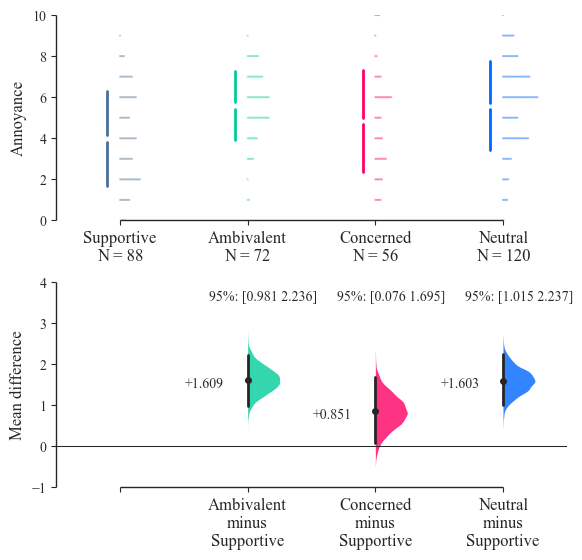

In [100]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataLoMD = dataLoloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                       raw_marker_size=0.1,
                                       swarmplot_kwargs={'alpha': 0.3},
                                       contrast_show_deltas=False,
                                       contrast_show_es=True, es_sf=3,
                                       custom_palette={'Neutral': mycolours[0],
                                                       'Ambivalent': mycolours[1],
                                                       'Concerned': mycolours[2],
                                                       'Supportive': mycolours[3]},
                                       swarm_desat=1,
                                       halfviolin_desat=1,
                                       bar_desat=1,
                                       es_marker_size=4,
                                       contrast_ylim=(-1, 4),
                                       ax=ax,
                                       )

diffs = np.round(dataLoloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB54AttDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB54AttDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataLoloadBL.mean_diff.statistical_tests])

dataLoMD;
dataLoloadBL.mean_diff.statistical_tests


In [101]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataLoloadBL.cohens_d.statistical_tests])
dataLoloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,88,72,Cohen's d,None,0.780972,95,0.460140,1.105184,0.000200,1.142550e-06,-5.064073,2.207513e-06,-4.914543,0.000010,1892.0
1,Supportive,Concerned,88,56,Cohen's d,None,0.356928,95,0.021573,0.707557,0.034993,4.239826e-02,-2.053312,3.858165e-02,-2.088023,0.075897,2034.0
2,Supportive,Neutral,88,120,Cohen's d,None,0.721117,95,0.436160,1.032087,0.000200,9.265112e-07,-5.082967,6.422447e-07,-5.138140,0.000002,3265.0


C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\3263792409.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtB60AttDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\3263792409.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB60AttDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\3263792409.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtB60AttDabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,88,72,mean difference,None,1.574495,95,0.968434,2.154040,0.000200,0.000001,-5.102123,0.000003,-4.859700,0.000028,1960.5
1,Supportive,Concerned,88,56,mean difference,None,0.709416,95,-0.108766,1.514610,0.095181,0.093127,-1.693097,0.091355,-1.699815,0.091117,2055.0
2,Supportive,Neutral,88,120,mean difference,None,1.185606,95,0.553030,1.810606,0.000800,0.000378,-3.624742,0.000297,-3.680528,0.000699,3838.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


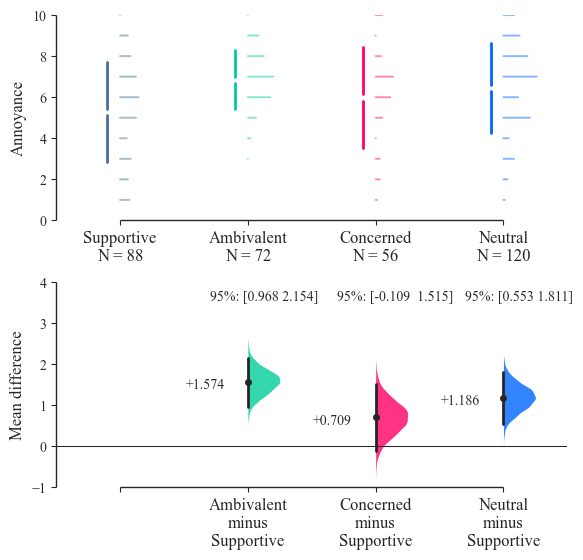

In [102]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataHiMD = dataHiloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                       raw_marker_size=0.1,
                                       swarmplot_kwargs={'alpha': 0.3},
                                       contrast_show_deltas=False,
                                       contrast_show_es=True, es_sf=3,
                                       custom_palette={'Neutral': mycolours[0],
                                                       'Ambivalent': mycolours[1],
                                                       'Concerned': mycolours[2],
                                                       'Supportive': mycolours[3]},
                                       swarm_desat=1,
                                       halfviolin_desat=1,
                                       bar_desat=1,
                                       es_marker_size=4,
                                       contrast_ylim=(-1, 4),
                                       ax=ax,
                                       )

diffs = np.round(dataHiloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtB60AttDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtB60AttDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataHiloadBL.mean_diff.statistical_tests])

dataHiMD;
dataHiloadBL.mean_diff.statistical_tests


In [103]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataHiloadBL.cohens_d.statistical_tests])
dataHiloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,88,72,Cohen's d,None,0.772257,95,0.463509,1.062489,0.000200,0.000001,-5.102123,0.000003,-4.859700,0.000028,1960.5
1,Supportive,Concerned,88,56,Cohen's d,None,0.290568,95,-0.055265,0.629421,0.095381,0.093127,-1.693097,0.091355,-1.699815,0.091117,2055.0
2,Supportive,Neutral,88,120,Cohen's d,None,0.516547,95,0.232302,0.794749,0.000800,0.000378,-3.624742,0.000297,-3.680528,0.000699,3838.5


### Home residence area

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTestB
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'Home_Area', 'Annoyance']]


In [105]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Urban', 'Suburban', 'Rural'],
                         x='Home_Area', y='Annoyance', resamples=5000, random_seed=24624)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1857538531.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtBAORDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1857538531.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBAORDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1857538531.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtBAORDabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,432,224,mean difference,None,1.161872,95,0.818452,1.499504,0.0002,1.262030e-11,-6.911108,6.802420e-10,-6.263983,1.818505e-08,35546.5
1,Urban,Rural,432,16,mean difference,None,2.407407,95,1.678241,3.053241,0.0004,2.360354e-06,-6.666549,1.152023e-04,-3.890693,6.250463e-05,1434.0


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


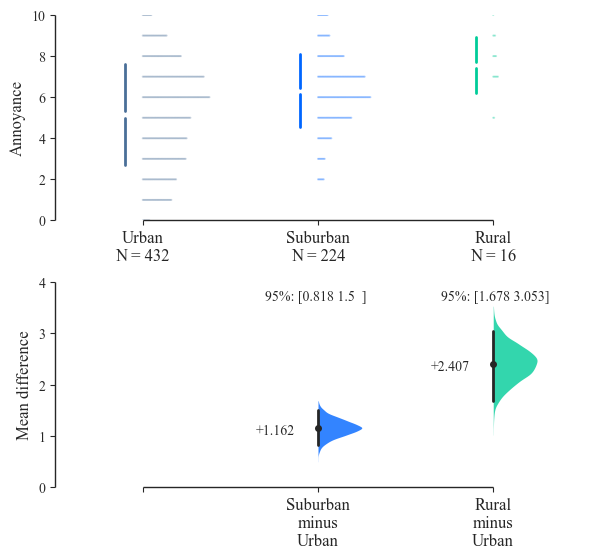

In [106]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.05,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Suburban': mycolours[0],
                                                   'Rural': mycolours[1],
                                                   'Urban': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(0, 4),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtBAORDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtBAORDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [107]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,432,224,Cohen's d,None,0.515747,95,0.361976,0.664886,0.0002,1.262030e-11,-6.911108,6.802420e-10,-6.263983,1.818505e-08,35546.5
1,Urban,Rural,432,16,Cohen's d,None,0.990522,95,0.688414,1.260290,0.0004,2.360354e-06,-6.666549,1.152023e-04,-3.890693,6.250463e-05,1434.0


## Parts A and B combined

### AAM attitude

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AAM_attitude', 'Annoyance']]


In [30]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Supportive', 'Ambivalent', 'Concerned', 'Neutral'],
                         x='AAM_attitude', y='Annoyance', resamples=5000, random_seed=3487)


In [31]:
len(data)

3870

C:\Users\m_lot\AppData\Local\Temp\ipykernel_41468\216971423.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtsABAttDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_41468\216971423.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAttDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_41468\216971423.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAttDabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,1034,768,mean difference,None,0.795261,95,0.577233,1.022488,0.0002,8.029949e-12,-6.884668,2.165023e-11,-6.737269,6.909585e-11,326288.0
1,Supportive,Concerned,1034,658,mean difference,None,0.657917,95,0.421525,0.902459,0.0002,7.900013e-08,-5.395853,1.695260e-07,-5.251998,3.037012e-07,290326.5
2,Supportive,Neutral,1034,1410,mean difference,None,1.339781,95,1.133720,1.545841,0.0002,6.911693e-36,-12.737735,1.431297e-36,-12.841101,2.165400e-32,525950.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


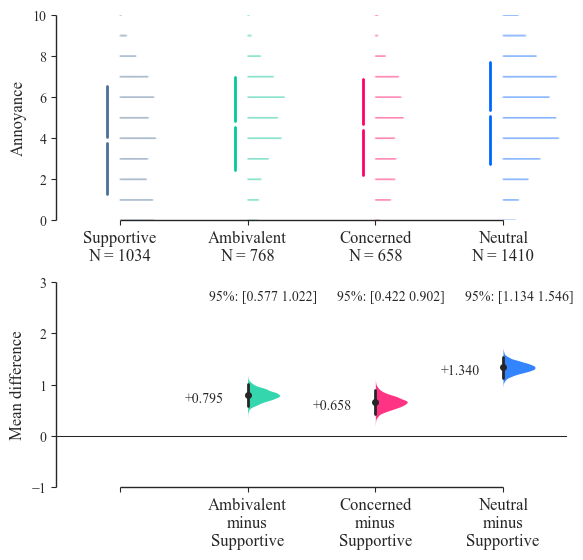

In [37]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.004,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Neutral': mycolours[0],
                                                   'Ambivalent': mycolours[1],
                                                   'Concerned': mycolours[2],
                                                   'Supportive': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-1, 3),
                                   ax=ax,
                                  )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABAttDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAttDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [38]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,1034,768,Cohen's d,None,0.320937,95,0.231029,0.414452,0.0002,8.029949e-12,-6.884668,2.165023e-11,-6.737269,6.909585e-11,326288.0
1,Supportive,Concerned,1034,658,Cohen's d,None,0.261910,95,0.166078,0.359517,0.0002,7.900013e-08,-5.395853,1.695260e-07,-5.251998,3.037012e-07,290326.5
2,Supportive,Neutral,1034,1410,Cohen's d,None,0.525755,95,0.443949,0.609778,0.0002,6.911693e-36,-12.737735,1.431297e-36,-12.841101,2.165400e-32,525950.5


#### Test the change in annoyance outcome variable

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'AAM_attitude', 'dAnnoyance']]


In [41]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Supportive', 'Ambivalent', 'Concerned', 'Neutral'],
                         x='AAM_attitude', y='dAnnoyance', resamples=5000, random_seed=3487)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,1034,768,mean difference,None,0.727270,95,0.450055,0.980474,0.0002,4.110218e-08,-5.518859,7.856602e-09,-5.799123,1.201388e-08,335449.0
1,Supportive,Concerned,1034,658,mean difference,None,0.512434,95,0.278530,0.758497,0.0002,2.091600e-05,-4.271084,1.133918e-05,-4.403120,3.004774e-07,290581.5
2,Supportive,Neutral,1034,1410,mean difference,None,0.903417,95,0.688781,1.107672,0.0002,5.683063e-17,-8.432974,1.648575e-15,-8.018122,2.986167e-16,589186.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


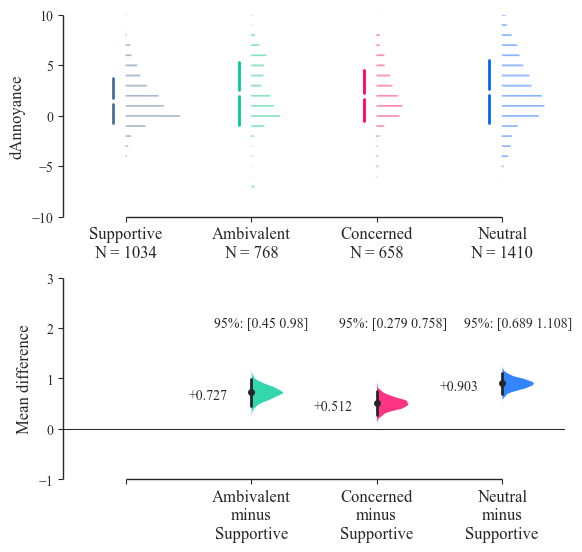

In [43]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-10, 10),
                                   raw_marker_size=0.0025,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Neutral': mycolours[0],
                                                   'Ambivalent': mycolours[1],
                                                   'Concerned': mycolours[2],
                                                   'Supportive': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-1, 3),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-20.9, s="95%: " + str(diffrow[1:]), fontsize=10)

#if saveplots:
#    plt.savefig(os.path.join(outFigPath, "svg", "PtsABAttDabestBase.svg"),
 #               #format='svg', bbox_inches='tight')
#    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAttDabestBase.pdf"),
 #               format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests


In [44]:
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Supportive,Ambivalent,1034,768,Cohen's d,None,0.276248,95,0.168635,0.375384,0.0002,4.110218e-08,-5.518859,7.856602e-09,-5.799123,1.201388e-08,335449.0
1,Supportive,Concerned,1034,658,Cohen's d,None,0.219577,95,0.116067,0.324939,0.0002,2.091600e-05,-4.271084,1.133918e-05,-4.403120,3.004774e-07,290581.5
2,Supportive,Neutral,1034,1410,Cohen's d,None,0.328287,95,0.250248,0.403301,0.0002,5.683063e-17,-8.432974,1.648575e-15,-8.018122,2.986167e-16,589186.5


### Home residence area

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'Home_Area', 'Annoyance']]


In [113]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Urban', 'Suburban', 'Rural'],
                         x='Home_Area', y='Annoyance', resamples=5000, random_seed=931)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1780213253.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtsABAORDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1780213253.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAORDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\1780213253.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAORDabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2538,1238,mean difference,None,0.798491,95,0.640195,0.953222,0.000200,5.121281e-23,-9.962372,2.599062e-20,-9.287360,3.998285e-17,1308218.0
1,Urban,Rural,2538,94,mean difference,None,-0.021277,95,-0.556344,0.532309,0.933813,9.397852e-01,0.075730,9.386525e-01,0.076971,8.717717e-01,120447.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


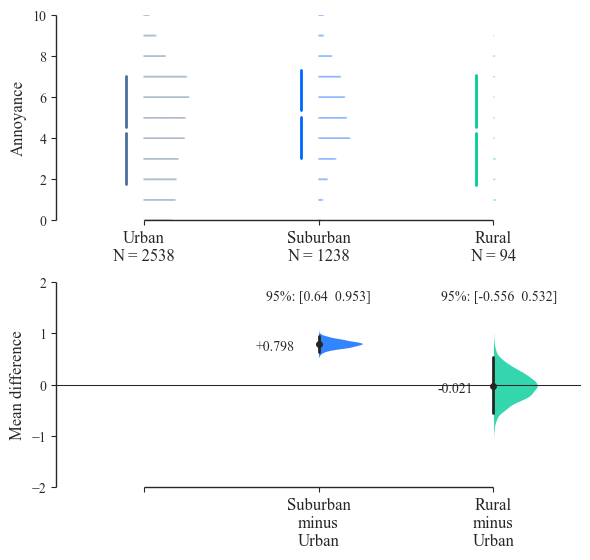

In [114]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Suburban': mycolours[0],
                                                   'Rural': mycolours[1],
                                                   'Urban': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 2),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABAORDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAORDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [115]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2538,1238,Cohen's d,None,0.321960,95,0.257970,0.384492,0.000200,5.121281e-23,-9.962372,2.599062e-20,-9.287360,3.998285e-17,1308218.0
1,Urban,Rural,2538,94,Cohen's d,None,-0.008085,95,-0.212187,0.202582,0.933813,9.397852e-01,0.075730,9.386525e-01,0.076971,8.717717e-01,120447.5


#### Change in annoyance

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'Home_Area', 'dAnnoyance']]


In [46]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Urban', 'Suburban', 'Rural'],
                         x='Home_Area', y='dAnnoyance', resamples=5000, random_seed=931)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2538,1238,mean difference,None,0.813085,95,0.622515,1.016301,0.0002,1.614984e-15,-8.027153,5.610790e-17,-8.412729,1.096864e-17,1303824.5
1,Urban,Rural,2538,94,mean difference,None,1.190701,95,0.654846,1.771080,0.0002,7.928892e-05,-4.117171,2.069209e-05,-4.265041,7.993988e-05,91036.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


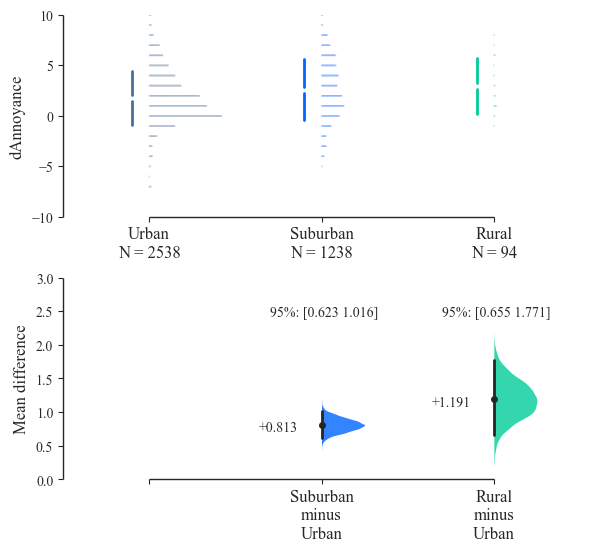

In [50]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-10, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Suburban': mycolours[0],
                                                   'Rural': mycolours[1],
                                                   'Urban': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(0, 3),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-19.9, s="95%: " + str(diffrow[1:]), fontsize=10)

#if saveplots:
#    plt.savefig(os.path.join(outFigPath, "svg", "PtsABAORDabestBase.svg"),
#                format='svg', bbox_inches='tight')
#    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABAORDabestBase.pdf"),
  #              format='pdf', bbox_inches='tight')
#out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [51]:
# calculate and display Cohen's d
#outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Urban,Suburban,2538,1238,Cohen's d,None,0.291640,95,0.222523,0.365355,0.0002,1.614984e-15,-8.027153,5.610790e-17,-8.412729,1.096864e-17,1303824.5
1,Urban,Rural,2538,94,Cohen's d,None,0.447978,95,0.247184,0.670621,0.0002,7.928892e-05,-4.117171,2.069209e-05,-4.265041,7.993988e-05,91036.5


### Area soundscape character

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'Area_soundscape', 'Annoyance']]


In [117]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Monotonous', 'Calm', 'Chaotic', 'Vibrant'],
                         x='Area_soundscape', y='Annoyance', resamples=5000, random_seed=21064694)


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\dabest-2024.3.29-py3.10.egg\dabest\plot_tools.py:1232: UserWarning: 1.0% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\338249314.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtsABScapeDabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\338249314.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABScapeDabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_1912\338249314.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all 

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Monotonous,Calm,376,1880,mean difference,None,0.154787,95,-0.112234,0.421277,0.247750,0.256800,-1.135209,0.252224,-1.145258,2.000882e-01,338777.0
1,Monotonous,Chaotic,376,376,mean difference,None,0.430851,95,0.050532,0.784574,0.018396,0.020444,-2.323075,0.020442,-2.323075,2.244985e-03,61651.0
2,Monotonous,Vibrant,376,1238,mean difference,None,0.688692,95,0.412268,0.972760,0.000200,0.000003,-4.732668,0.000007,-4.520023,9.778189e-07,194234.0


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


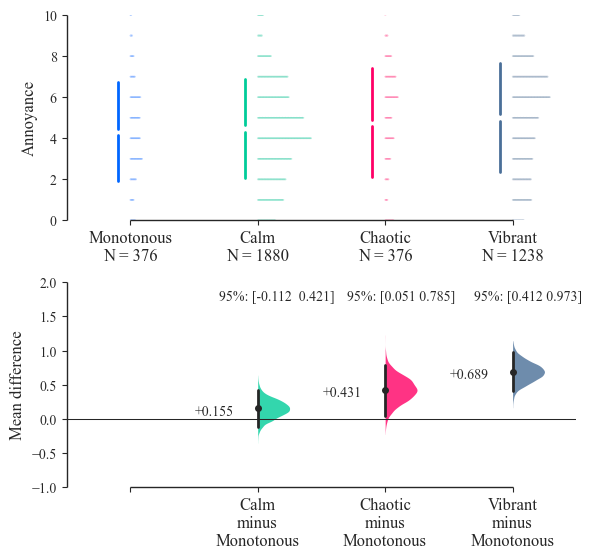

In [118]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.002,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Monotonous': mycolours[0],
                                                   'Calm': mycolours[1],
                                                   'Chaotic': mycolours[2],
                                                   'Vibrant': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-1, 2),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABScapeDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABScapeDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [119]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Monotonous,Calm,376,1880,Cohen's d,None,0.064699,95,-0.046910,0.176512,0.247750,0.256800,-1.135209,0.252224,-1.145258,2.000882e-01,338777.0
1,Monotonous,Chaotic,376,376,Cohen's d,None,0.169428,95,0.020655,0.313304,0.018596,0.020444,-2.323075,0.020442,-2.323075,2.244985e-03,61651.0
2,Monotonous,Vibrant,376,1238,Cohen's d,None,0.266157,95,0.158168,0.378919,0.000200,0.000003,-4.732668,0.000007,-4.520023,9.778189e-07,194234.0


#### Change in annoyance

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'Area_soundscape', 'dAnnoyance']]


In [53]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['Monotonous', 'Calm', 'Chaotic', 'Vibrant'],
                         x='Area_soundscape', y='dAnnoyance', resamples=5000, random_seed=21064694)


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\dabest-2024.3.29-py3.10.egg\dabest\plot_tools.py:1232: UserWarning: 0.6% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Monotonous,Calm,376,1880,mean difference,None,0.054787,95,-0.231915,0.334043,0.731454,0.708150,-0.374523,0.732123,-0.342345,0.753258,349843.0
1,Monotonous,Chaotic,376,376,mean difference,None,0.638298,95,0.234043,1.031915,0.002200,0.001631,-3.162103,0.001629,-3.162103,0.003721,62109.5
2,Monotonous,Vibrant,376,1238,mean difference,None,-0.310569,95,-0.609055,-0.023253,0.049590,0.040101,2.056802,0.046923,1.988522,0.006927,253914.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


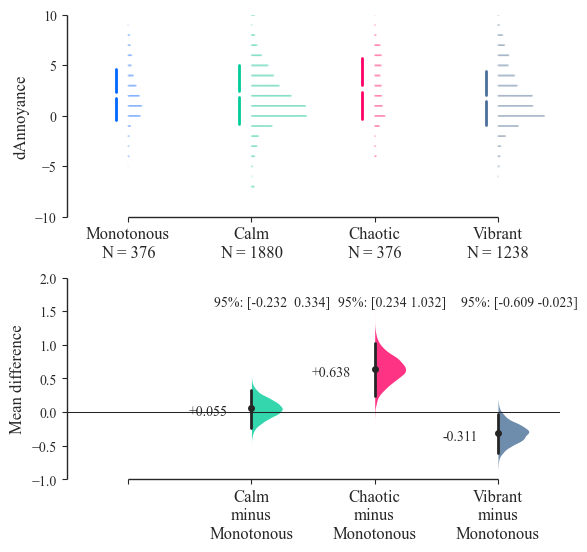

In [56]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-10, 10),
                                   raw_marker_size=0.0015,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'Monotonous': mycolours[0],
                                                   'Calm': mycolours[1],
                                                   'Chaotic': mycolours[2],
                                                   'Vibrant': mycolours[3]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-1, 2),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-18.9, s="95%: " + str(diffrow[1:]), fontsize=10)

#if saveplots:
 #   plt.savefig(os.path.join(outFigPath, "svg", "PtsABScapeDabestBase.svg"),
  #              format='svg', bbox_inches='tight')
#    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABScapeDabestBase.pdf"),
#                format='pdf', bbox_inches='tight')
#out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [55]:
# calculate and display Cohen's d
#outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,Monotonous,Calm,376,1880,Cohen's d,None,0.019340,95,-0.081652,0.118514,0.731454,0.708150,-0.374523,0.732123,-0.342345,0.753258,349843.0
1,Monotonous,Chaotic,376,376,Cohen's d,None,0.230620,95,0.084127,0.374091,0.002200,0.001631,-3.162103,0.001629,-3.162103,0.003721,62109.5
2,Monotonous,Vibrant,376,1238,Cohen's d,None,-0.117092,95,-0.229933,-0.007892,0.051390,0.040101,2.056802,0.046923,1.988522,0.006927,253914.5


### Nationality region

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]


In [121]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Africa', 'EastAsia', 'MidEast', 'SouthAsia', 'Europe', 'SouthAmerica', 'Australasia'],
                         x='NationGeo', y='Annoyance', resamples=5000, random_seed=65494894)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,mean difference,None,-1.216223,95,-1.433673,-0.997593,0.000200,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,EastAsia,1708,376,mean difference,None,0.438033,95,0.167236,0.706519,0.002000,1.663058e-03,-3.160110,1.674955e-03,-3.146637,3.369082e-03,290350.0
2,UK,MidEast,1708,282,mean difference,None,1.313033,95,1.042790,1.574526,0.000200,3.884421e-19,-9.395614,3.732686e-17,-8.497746,7.427490e-19,162126.5
3,UK,SouthAsia,1708,188,mean difference,None,-0.910372,95,-1.186631,-0.631970,0.000200,8.467463e-10,6.361590,7.759408e-07,4.957950,6.296411e-08,198811.5
4,UK,Europe,1708,94,mean difference,None,0.621543,95,0.245117,0.989972,0.014597,1.329701e-03,-3.290645,1.523101e-02,-2.429163,2.134054e-02,69053.0
5,UK,SouthAmerica,1708,94,mean difference,None,2.919416,95,2.427027,3.339877,0.000200,5.121429e-23,-12.679337,8.725824e-29,-11.328408,8.778196e-26,29055.0
6,UK,Australasia,1708,94,mean difference,None,1.610905,95,1.237319,1.965581,0.000200,1.886095e-14,-8.762659,3.714025e-10,-6.300797,5.720153e-11,48333.0


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


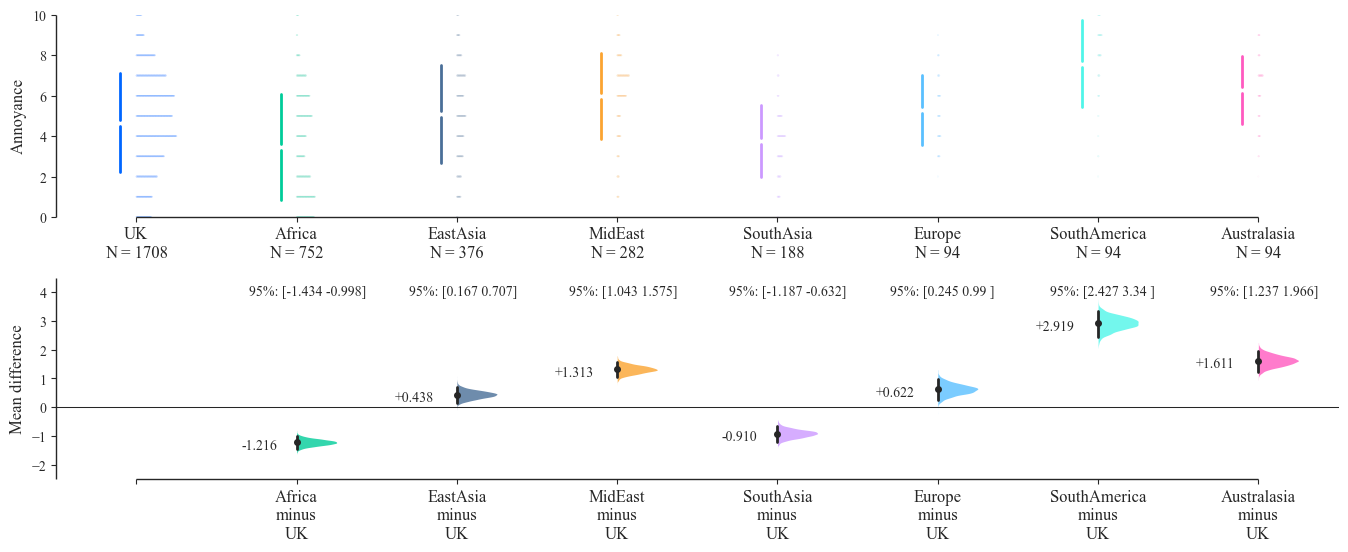

In [122]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(13.71, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa': mycolours[1],
                                                   'EastAsia': mycolours[3],
                                                   'MidEast': mycolours[4],
                                                   'SouthAsia': mycolours[5],
                                                   'Europe': mycolours[6],
                                                   'SouthAmerica': mycolours[7],
                                                   'Australasia': mycolours[8]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2.5, 4.5),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

dataMD;
dataloadBL.mean_diff.statistical_tests


In [123]:
# calculate and display Cohen's d
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,Cohen's d,None,-0.485389,95,-0.575995,-0.397099,0.000200,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,EastAsia,1708,376,Cohen's d,None,0.179249,95,0.067193,0.288327,0.002000,1.663058e-03,-3.160110,1.674955e-03,-3.146637,3.369082e-03,290350.0
2,UK,MidEast,1708,282,Cohen's d,None,0.546213,95,0.431696,0.659420,0.000200,3.884421e-19,-9.395614,3.732686e-17,-8.497746,7.427490e-19,162126.5
3,UK,SouthAsia,1708,188,Cohen's d,None,-0.380977,95,-0.498913,-0.265947,0.000200,8.467463e-10,6.361590,7.759408e-07,4.957950,6.296411e-08,198811.5
4,UK,Europe,1708,94,Cohen's d,None,0.257351,95,0.102074,0.411162,0.014597,1.329701e-03,-3.290645,1.523101e-02,-2.429163,2.134054e-02,69053.0
5,UK,SouthAmerica,1708,94,Cohen's d,None,1.200158,95,0.988500,1.382107,0.000200,5.121429e-23,-12.679337,8.725824e-29,-11.328408,8.778196e-26,29055.0
6,UK,Australasia,1708,94,Cohen's d,None,0.667521,95,0.510903,0.818811,0.000200,1.886095e-14,-8.762659,3.714025e-10,-6.300797,5.720153e-11,48333.0


#### Change in annoyance (all)

In [ ]:
# select subset of data for analysis and sort
data = dataBySubjTest
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'dAnnoyance']]


In [63]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Africa', 'EastAsia', 'MidEast', 'SouthAsia', 'Europe', 'SouthAmerica', 'Australasia'],
                         x='NationGeo', y='dAnnoyance', resamples=5000, random_seed=65494894)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,mean difference,None,-1.457802,95,-1.695236,-1.242183,0.000200,3.264923e-34,12.486062,6.891812e-32,11.920332,6.218617e-33,834566.0
1,UK,EastAsia,1708,376,mean difference,None,-1.003015,95,-1.319977,-0.644869,0.000200,9.340894e-09,5.834903,1.900764e-09,6.032907,1.965176e-09,384107.5
2,UK,MidEast,1708,282,mean difference,None,0.128191,95,-0.190746,0.464161,0.487103,4.349842e-01,-0.781446,4.821799e-01,-0.702933,1.395154e-01,227701.0
3,UK,SouthAsia,1708,188,mean difference,None,-0.045568,95,-0.343527,0.264164,0.822236,7.703315e-01,0.292214,8.328017e-01,0.211139,6.685437e-01,157521.0
4,UK,Europe,1708,94,mean difference,None,0.486347,95,0.008807,0.997646,0.106579,6.003942e-02,-1.900351,1.094093e-01,-1.601646,6.949062e-02,71415.5
5,UK,SouthAmerica,1708,94,mean difference,None,0.539539,95,-0.135346,1.216378,0.072985,1.308523e-01,-1.523164,8.095871e-02,-1.746131,2.881281e-01,75090.0
6,UK,Australasia,1708,94,mean difference,None,-1.183866,95,-1.689147,-0.601986,0.000400,4.002268e-05,4.286834,1.054395e-04,3.886375,1.201552e-05,101639.0


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


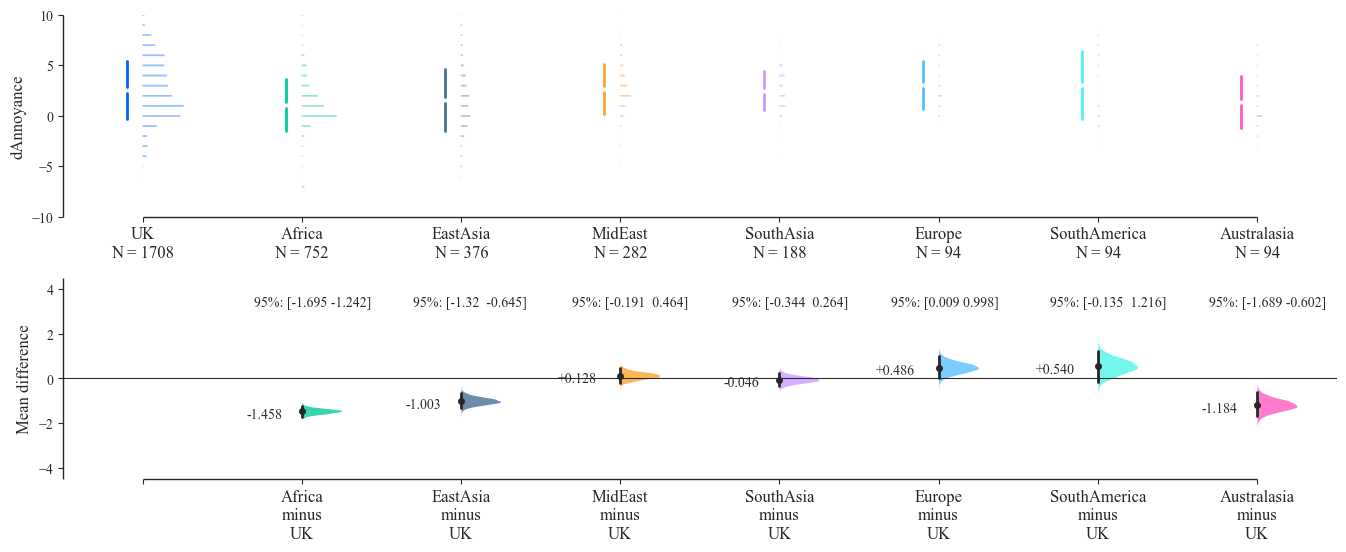

In [64]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(13.71, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-10, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa': mycolours[1],
                                                   'EastAsia': mycolours[3],
                                                   'MidEast': mycolours[4],
                                                   'SouthAsia': mycolours[5],
                                                   'Europe': mycolours[6],
                                                   'SouthAmerica': mycolours[7],
                                                   'Australasia': mycolours[8]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-4.5, 4.5),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-18.9, s="95%: " + str(diffrow[1:]), fontsize=10)

dataMD;
dataloadBL.mean_diff.statistical_tests


#### 2 groups: UK vs Africa

In [124]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Africa'],
                         x='NationGeo', y='Annoyance', resamples=5000, random_seed=65494894)

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,mean difference,None,-1.216223,95,-1.433673,-0.997593,0.0002,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5


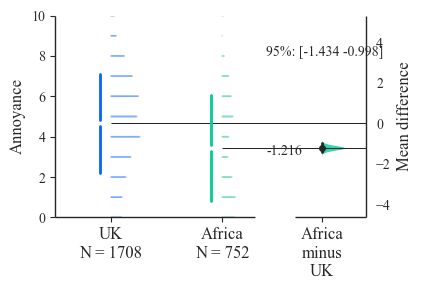

In [125]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(4.29, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa': mycolours[1]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 0),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=1.4 + ii, y=8, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABNationDabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNationDabestBase.pdf"),
                format='pdf', bbox_inches='tight')
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [126]:
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,Cohen's d,None,-0.485389,95,-0.575995,-0.397099,0.0002,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5


#### Combining all non-UK regions into one 'other' group

In [ ]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] != "UK") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]


In [264]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Other'],
                         x='NationGeo', y='Annoyance', resamples=5000, random_seed=5954984962)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Other,1708,1880,mean difference,None,-0.035372,95,-0.20825,0.12976,0.664867,0.67756,0.415828,0.678713,0.414254,0.906672,1609130.5


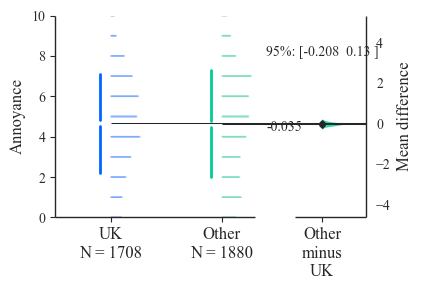

In [265]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(4.29, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Other': mycolours[1]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 0),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=1.4 + ii, y=8, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABNation2DabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation2DabestBase.pdf"),
                format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests


In [266]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Other,1708,1880,Cohen's d,None,-0.013847,95,-0.080897,0.050865,0.664867,0.67756,0.415828,0.678713,0.414254,0.906672,1609130.5


##### Change in annoyance

In [ ]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] != "UK") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'dAnnoyance']]


In [268]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Other'],
                         x='NationGeo', y='dAnnoyance', resamples=5000, random_seed=5954984962)


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Other,1708,1880,mean difference,None,-0.776951,95,-0.968221,-0.592596,0.0002,2.268360e-16,8.247128,1.887043e-16,8.268633,1.089086e-15,1852040.0


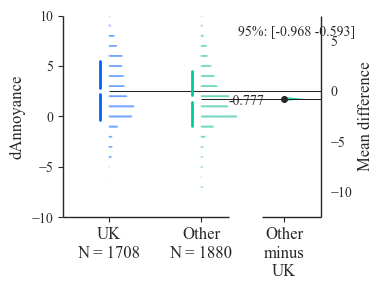

In [258]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(4.29, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-10, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Other': mycolours[1]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 0),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=1.4 + ii, y=8, s="95%: " + str(diffrow[1:]), fontsize=10)

#if saveplots:
#    plt.savefig(os.path.join(outFigPath, "svg", "PtsABNation2DabestBase.svg"),
#                format='svg', bbox_inches='tight')
#    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation2DabestBase.pdf"),
#                format='pdf', bbox_inches='tight')
#out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [259]:
# calculate and display Cohen's d
#outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Other,1708,1880,Cohen's d,None,-0.276399,95,-0.343614,-0.209713,0.0002,2.268360e-16,8.247128,1.887043e-16,8.268633,1.089086e-15,1852040.0


Combining all non-UK regions except Africa into one 'other' group

In [ ]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] != "UK") & (data['NationGeo'] != "Africa") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]


In [246]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Africa', 'Other'],
                         x='NationGeo', y='Annoyance', resamples=5000, random_seed=454515665)


C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1558372705.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtsABNation3DabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1558372705.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation3DabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1558372705.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation3DabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,mean difference,None,-1.216223,95,-1.429649,-0.997854,0.0002,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,Other,1708,1128,mean difference,None,0.751862,95,0.564766,0.926425,0.0002,3.649696e-16,-8.205360,5.984273e-16,-8.137288,5.524505e-15,797729.0


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


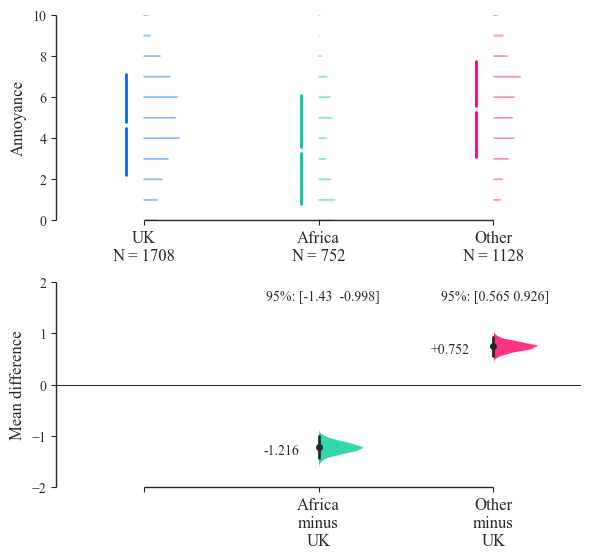

In [247]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa': mycolours[1],
                                                   'Other': mycolours[2]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 2),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    #ax.text(x=0.8 + ii, y=-10.9, s=" " + str(diffrow[0]), fontsize=10)
    ax.text(x=0.7 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)

if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABNation3DabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation3DabestBase.pdf"),
                format='pdf', bbox_inches='tight')

dataMD;
dataloadBL.mean_diff.statistical_tests


In [249]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa,1708,752,Cohen's d,None,-0.485389,95,-0.574985,-0.396237,0.0002,4.970285e-26,10.776461,6.295599e-28,11.091125,9.463814e-26,811401.5
1,UK,Other,1708,1128,Cohen's d,None,0.312201,95,0.234384,0.385790,0.0002,3.649696e-16,-8.205360,5.984273e-16,-8.137288,5.524505e-15,797729.0


#### Combine Africa and South Asia into one group

In [272]:
dataBySubjTest['NativeLang'].unique()


array(['Other', 'English'], dtype=object)

In [ ]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] == "Africa") | (data['NationGeo'] == "SouthAsia"), 'NationGeo'] = "Africa_SAsia"
data.loc[(data['NationGeo'] != "UK") & (data['NationGeo'] != "Africa_SAsia") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'Annoyance']]


In [270]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Africa_SAsia', 'Other'],
                         x='NationGeo', y='Annoyance', resamples=5000, random_seed=761278622)

C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1052726916.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "svg", "PtsABNation4DabestBase.svg"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1052726916.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation4DabestBase.pdf"),
C:\Users\m_lot\AppData\Local\Temp\ipykernel_37572\1052726916.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation4DabestBase.pdf"),


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa_SAsia,1708,940,mean difference,None,-1.155053,95,-1.356677,-0.952437,0.0002,1.349025e-29,11.490964,3.826047e-30,11.550551,1.373441e-28,1010213.0
1,UK,Other,1708,940,mean difference,None,1.084309,95,0.896828,1.274817,0.0002,7.108734e-29,-11.324787,3.594176e-28,-11.133752,1.083899e-27,598917.5


C:\Users\m_lot\OneDrive - University of Salford\Code\DABEST-python_devMJBL\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


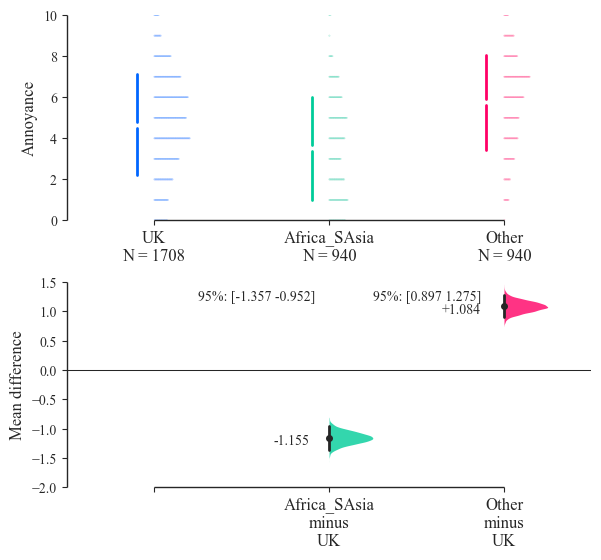

In [271]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(0, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa_SAsia': mycolours[1],
                                                   'Other': mycolours[2]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 1.5),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    ax.text(x=0.25 + ii, y=-3.9, s="95%: " + str(diffrow[1:]), fontsize=10)


if saveplots:
    plt.savefig(os.path.join(outFigPath, "svg", "PtsABNation4DabestBase.svg"),
                format='svg', bbox_inches='tight')
    plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation4DabestBase.pdf"),
                format='pdf', bbox_inches='tight')


dataMD;
dataloadBL.mean_diff.statistical_tests


In [253]:
out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])
# calculate and display Cohen's d
outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,UK,Africa_SAsia,1708,940,Cohen's d,None,-0.469087,95,-0.553774,-0.384737,0.0002,1.349025e-29,11.490964,3.826047e-30,11.550551,1.373441e-28,1010213.0
1,UK,Other,1708,940,Cohen's d,None,0.452161,95,0.372888,0.533991,0.0002,7.108734e-29,-11.324787,3.594176e-28,-11.133752,1.083899e-27,598917.5


##### Change in annoyance

In [ ]:
# create new subset of data for analysis and sort
data = dataBySubjTest.copy()
data.loc[(data['NationGeo'] == "Africa") | (data['NationGeo'] == "SouthAsia"), 'NationGeo'] = "Africa_SAsia"
data.loc[(data['NationGeo'] != "UK") & (data['NationGeo'] != "Africa_SAsia") & ~data['NationGeo'].isna(), 'NationGeo'] = "Other"
data = data[data['UASLAeq'] != "Baseline"]
data = data.loc[:, ['ID', 'StimFile', 'UASLAeq', 'NationGeo', 'dAnnoyance']]


SyntaxError: invalid syntax. Perhaps you forgot a comma? (2268601429.py, line 4)

In [ ]:
# assign data for processing
dataloadBL = dabest.load(data=data, idx=['UK', 'Africa_SAsia', 'Other'],
                         x='NationGeo', y='dAnnoyance', resamples=5000, random_seed=761278622)

In [ ]:
# calculate baseline paired effect sizes and plot
fig, ax = plt.subplots(figsize=(6, 3))
dataMD = dataloadBL.mean_diff.plot(swarm_ylim=(-10, 10),
                                   raw_marker_size=0.001,
                                   swarmplot_kwargs={'alpha': 0.3},
                                   contrast_show_deltas=False,
                                   contrast_show_es=True, es_sf=3,
                                   custom_palette={'UK': mycolours[0],
                                                   'Africa_SAsia': mycolours[1],
                                                   'Other': mycolours[2]},
                                   swarm_desat=1,
                                   halfviolin_desat=1,
                                   bar_desat=1,
                                   es_marker_size=4,
                                   contrast_ylim=(-2, 1.5),
                                   ax=ax,
                                   )

diffs = np.round(dataloadBL.mean_diff.statistical_tests[['difference', 'bca_low', 'bca_high']].values, 3)
# label results
for ii, diffrow in enumerate(diffs):
    ax.text(x=0.7 + ii, y=-19.9, s="95%: " + str(diffrow[1:]), fontsize=10)


#if saveplots:
 #   plt.savefig(os.path.join(outFigPath, "svg", "PtsABNation4DabestBase.svg"),
 #               format='svg', bbox_inches='tight')
 #   plt.savefig(os.path.join(outFigPath, "pdf", "PtsABNation4DabestBase.pdf"),
 #               format='pdf', bbox_inches='tight')
#out = pd.concat([out, dataloadBL.mean_diff.statistical_tests])

dataMD;
dataloadBL.mean_diff.statistical_tests


In [ ]:
# calculate and display Cohen's d
#outd = pd.concat([outd, dataloadBL.cohens_d.statistical_tests])
dataloadBL.cohens_d.statistical_tests


## Save output data to file

In [135]:
if savedata:
    out.to_csv(os.path.join(outDataPath, "dabest_mean_diff.csv"))
    outd.to_csv(os.path.join(outDataPath, "dabest_cohens_d.csv"))

# Comparison with DroneNoise data

In [136]:
dataDNoiseWide = pd.read_csv(r"C:\Users\m_lot\OneDrive - University of Salford\REFMAP General\03 Experiment\Experiment 1\Analysis\Comparison_data\DroneNoise2022AnnoyWide.csv")

dataDNoiseLong = dataDNoiseWide.melt(id_vars='ID', var_name='StimFile', value_name='Annoyance')
dataDNoiseLong.head()

,ID,StimFile,Annoyance
0,1,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,0.9
1,2,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,2.0
2,3,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,0.7
3,4,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,0.6
4,6,GD28X_Event-210_mic2_Fast_FO_Closed CAL.wav,1.5


In [137]:
dataDNoiseLong['UASOperation'] = "Flyby"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Landing"), 'UASOperation'] = "Landing"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Takeoff"), 'UASOperation'] = "Takeoff"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Hover"), 'UASOperation'] = "Hover"
dataDNoiseLong['Location'] = "Outdoors"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Part_Open"), 'Location'] = "Indoors_PO"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("Closed"), 'Location'] = "Indoors_Cl"
dataDNoiseLong['UASType'] = "Typhoon"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("GD28X"), 'UASType'] = "GD28X"
dataDNoiseLong.loc[dataDNoiseLong['StimFile'].str.contains("M200"), 'UASType'] = "M200"

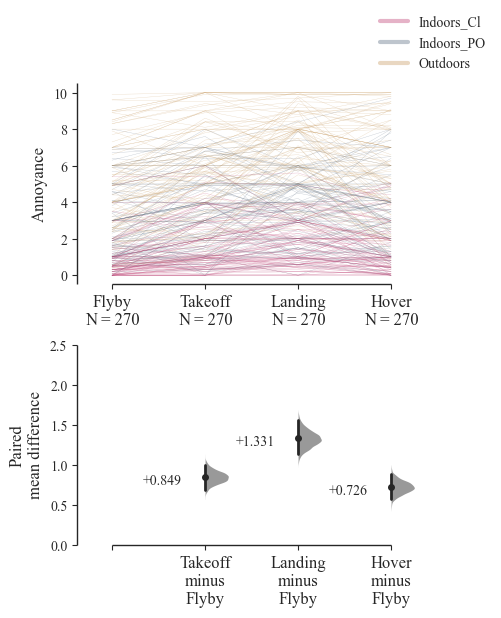

In [138]:
dataDNoiseLong.sort_values(by=['ID', 'Location', 'UASType', 'UASOperation'], inplace=True)
dataDNoiseLong['dummyID'] = np.repeat(np.arange(1, len(dataDNoiseLong['ID'])//len(dataDNoiseLong['UASOperation'].unique()) + 1, dtype=int), len(dataDNoiseLong['UASOperation'].unique()), axis=0)

dataDNoiseloadBL = dabest.load(data=dataDNoiseLong, idx=("Flyby", "Takeoff", "Landing", "Hover"),
                               x='UASOperation', y='Annoyance', paired='baseline',
                               id_col='dummyID', resamples=5000, random_seed=646)

dataDNoiseBL = dataDNoiseloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='Location',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.4},
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[2:], es_marker_size=4, contrast_ylim=(0, 2.5),
                                               legend_kwargs={'loc': 'lower center'})


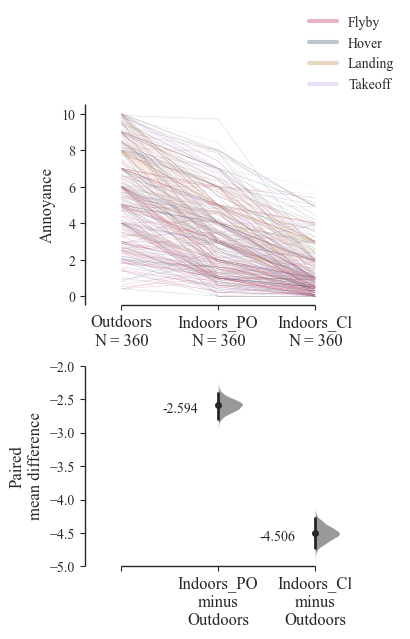

In [139]:
dataDNoiseLong.sort_values(by=['ID', 'UASOperation', 'UASType', 'Location'], inplace=True)
dataDNoiseLong['dummyID'] = np.repeat(np.arange(1, len(dataDNoiseLong['ID'])//len(dataDNoiseLong['Location'].unique()) + 1, dtype=int), len(dataDNoiseLong['Location'].unique()), axis=0)

dataDNoiseloadBL = dabest.load(data=dataDNoiseLong, idx=("Outdoors", "Indoors_PO", "Indoors_Cl"),
                               x='Location', y='Annoyance', paired='baseline',
                               id_col='dummyID', resamples=5000, random_seed=4546)

dataDNoiseBL = dataDNoiseloadBL.mean_diff.plot(swarm_ylim=(-0.5, 10.5), color_col='UASOperation',
                                               contrast_show_deltas=False, slopegraph_kwargs={'linewidth': 0.25, 'alpha': 0.4},
                                               contrast_show_es=True, es_sf=3,
                                               custom_palette=mycolours[2:], es_marker_size=4, contrast_ylim=(-5, -2),
                                               legend_kwargs={'loc': 'lower center'})
